# Notebook 03: Wildfire Clustering Around Lake Tahoe

**Obstacle-Aware Clustering for Geographic Data**

This notebook applies the obstacle-aware k-Means algorithm to real-world wildfire occurrence data around Lake Tahoe and tests when and why each component of the framework adds value.

### Main Findings

1. **The framework improves on standard k-Means** by 26% in mean arc-length span and more than doubles $\sigma_a$, but most of that improvement comes from optimizing the attribute weight $\gamma$ rather than from adding the arc-length parameter $s$.
2. **The arc-length parameter $s$ does most of its work for fires close to the obstacle.** On the full basin (where most fires are 2-10 km from shore), $s$ contributes only 2% of the geographic coherence improvement. Restricted to fires within 2 km of the lake, that contribution jumps to 26%.
3. **The algorithm's effectiveness scales with the fraction of points near the obstacle.** This is a finding about *when* obstacle-aware clustering matters, not just whether it works.

### Structure

The analysis runs in two tiers:

- **Tier 1 (Spatial Only)** compares standard k-Means against the obstacle-aware algorithm using only geographic and arc-length features. This isolates the effect of the arc-length parameter $s$ without attributes mixed in.
- **Tier 2 (Spatial + Attributes)** adds fire size and cause type to the feature vector, using the full distance metric. We compare three methods that differ from each other by a single change at a time -- standard k-Means, optimized k-Means without $s$, and optimized obstacle-aware -- to quantify the contribution of each component. A near-shore diagnostic at the end tests where $s$ contributes most.

### The Weighted Distance Metric

The obstacle-aware k-Means algorithm uses a composite distance that combines three domains. Between any two feature vectors $\mathbf{x}$ and $\mathbf{x}'$:

$$d^2(\mathbf{x}, \mathbf{x}') = \alpha^2 \cdot \|\text{geo} - \text{geo}'\|^2 + \beta^2 \cdot d_s(s, s')^2 + \gamma^2 \cdot \|\text{attr} - \text{attr}'\|^2$$

where:
- $\alpha$ controls the weight on **geographic** distance (Euclidean in scaled $x, y$)
- $\beta$ controls the weight on **arc-length** distance (loop-aware distance in $s$, the normalized position along the lake boundary)
- $\gamma$ controls the weight on **attribute** distance (Euclidean in fire size and cause type)

By tuning these weights, the algorithm can trade off among spatial proximity, obstacle-aware connectivity, and behavioral similarity.

### The Objective Function

To find the best weights, we minimize a composite objective:

$$J = \bar{\rho} + (1 - \sigma_a)$$

where $\bar{\rho}$ is the mean within-cluster distortion (lower = tighter clusters) and $\sigma_a \in [0,1]$ is the fraction of statistically significant pairwise attribute differences between clusters (higher = more distinct clusters). In Tier 1 where there are no attributes, $\sigma_a = 0$ and $J$ simplifies to $\bar{\rho}$. In Tier 2, we minimize $J$ with a grid search over the relevant weights for each method to find the optimal weighting.

---

## 1. Setup

In [52]:
import os
# Prevent sklearn/KMeans from spawning parallel threads on Windows
# (also suppresses a harmless OpenMP warning)
os.environ['OMP_NUM_THREADS'] = '1'

# Suppress unecessary warnings
import warnings
from scipy.integrate import IntegrationWarning
warnings.filterwarnings('ignore', category=IntegrationWarning)
warnings.filterwarnings('ignore', message='.*Intel OpenMP.*')

#Standard packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# For polygon clipping during boundary cleanup and basin filtering
from shapely.geometry import Polygon as ShapelyPolygon

# Database access for the FPA FOD wildfire data
import sqlite3

# Caching utilities so expensive cells only run once
import json as json_lib
import pickle
from pathlib import Path

# sklearn baselines and preprocessing
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# For finding attribute differences
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn


# Our custom package
from obstacle_clustering import (
    SplineBoundary, ObstacleKMeans,
    loop_aware_distance,
    optimize_weights, attribute_separation,
)
from obstacle_clustering.optimization import objective_function

# --- Plot style ---
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,           # base size — affects everything
    'axes.titlesize': 16,      # subplot titles
    'axes.labelsize': 14,      # x and y axis labels
    'xtick.labelsize': 12,     # x tick numbers
    'ytick.labelsize': 12,     # y tick numbers
    'legend.fontsize': 12,
    'figure.titlesize': 18,    # suptitle
})

# Consistent cluster colors across all plots in this notebook
CLUSTER_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# --- Caching ---
# Expensive cells (simulated annealing, objective surfaces) save their
# results so reruns are instant. Delete a file in cache_dir to force a rerun.
cache_dir = Path('../data/cached')
cache_dir.mkdir(parents=True, exist_ok=True)


def cached_or_run(cache_path, compute_fn, force_rerun=False):
    """Load from cache if it exists, otherwise run compute_fn and save."""
    cache_path = Path(cache_path)
    if cache_path.exists() and not force_rerun:
        print(f'Loading cached: {cache_path.name}')
        with open(cache_path, 'rb') as f:
            return pickle.load(f)
    print(f'Computing (will cache to {cache_path.name})...')
    result = compute_fn()
    with open(cache_path, 'wb') as f:
        pickle.dump(result, f)
    return result

# --- Helpers ---
def arc_length_span(s_values):
    """Calculate the arc-length span of a cluster on the loop [0, 1]."""
    if len(s_values) <= 1:
        return 0.0
    sorted_s = np.sort(s_values)
    gaps = np.diff(sorted_s)
    wrap_gap = (1.0 - sorted_s[-1]) + sorted_s[0]
    largest_gap = max(gaps.max(), wrap_gap)
    return 1.0 - largest_gap

def map_labels_to_reference(labels, reference_labels, k):
    """Map cluster labels so colors/IDs align with a reference labeling.
    
    For each new label, finds the reference label it overlaps with most.
    Greedy assignment ensures no two new labels map to the same reference.
    Useful for keeping cluster colors consistent across plots and for
    aligning per-cluster columns in comparison tables.
    """
    overlap = np.zeros((k, k), dtype=int)
    for i in range(k):
        for j in range(k):
            overlap[i, j] = np.sum((labels == i) & (reference_labels == j))
    
    mapping = {}
    used = set()
    sort_order = np.argsort(-overlap.max(axis=1))
    for i in sort_order:
        for j in np.argsort(-overlap[i]):
            if j not in used:
                mapping[i] = j
                used.add(j)
                break
    return mapping

## 2. Loading the Boundary Data

Two boundaries play distinct roles in this analysis. The **Lake Tahoe shoreline** (from Notebook 02) defines the obstacle and the arc-length parameter $s$ -- every fire gets projected onto this curve. The **Tahoe Regional Planning Agency (TRPA) basin polygon** defines our study area. We restrict the analysis to fires that fall inside the TRPA jurisdictional boundary.

### Lake Tahoe Shoreline (Obstacle)

In [53]:
# Load boundary from Notebook 02
boundary_df = pd.read_csv('../data/boundaries/lake_tahoe_boundary.csv')
lon_boundary = boundary_df['longitude'].values
lat_boundary = boundary_df['latitude'].values

# Fit cubic splines to the cleaned boundary coordinates from Notebook 02
boundary = SplineBoundary(x_coords=lon_boundary, y_coords=lat_boundary)

L = boundary.total_arc_length()
print(f'Lake Tahoe boundary: {len(lon_boundary)} vertices')
print(f'Total arc length: {L:.4f} degrees')

# Sample for plotting (reused throughout the notebook)
spline_pts = boundary.sample_boundary(n_points=500)

Lake Tahoe boundary: 269 vertices
Total arc length: 1.2027 degrees


### TRPA Basin (Study Area)

In [54]:
# Load the TRPA basin boundary (defines our study area)
basin_path = Path('../data/raw/trpa_boundary.geojson')
if not basin_path.exists():
    raise FileNotFoundError(
        f'{basin_path} not found. Download the TRPA Boundary GeoJSON from\n'
        f'https://www.tahoeopendata.org/datasets/TRPA::trpa-boundary/about\n'
        f'and place it at this path.'
    )

import json
with open(basin_path) as f:
    basin_geojson = json.load(f)

# Extract the polygon coordinates
basin_coords = basin_geojson['features'][0]['geometry']['coordinates'][0]
basin_polygon = ShapelyPolygon(basin_coords)

print(f'TRPA basin: {len(basin_coords)} vertices ')  

TRPA basin: 3387 vertices 


## 3. Loading Wildfire Data

The [Fire Program Analysis Fire-Occurrence Database (FPA FOD)](https://www.fs.usda.gov/rds/archive/catalog/RDS-2013-0009.6) is a national database of wildfires reported in the United States from 1992 to 2020. We query the SQLite database for fires within a bounding box around Lake Tahoe (roughly 38.85°–39.35° N, 120.25°–119.85° W), which captures fires on the shoreline and in the surrounding basin.

**Important**: The FPA FOD SQLite file is not included in this repository due to its size (~2 GB). To reproduce this analysis:
1. Download `FPA_FOD_20221014.sqlite` from the [USFS Research Data Archive](https://www.fs.usda.gov/rds/archive/catalog/RDS-2013-0009.6)
2. Rename to `fires.sqlite` and place in the `data/raw/` directory

In [55]:
# Connect to the FPA FOD SQLite database
db_path = '../data/raw/fires.sqlite'  

# Bounding box around the TRPA basin to limit the SQL pull
# (the actual basin polygon filter happens below after loading)
query = """
    SELECT LATITUDE, LONGITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,
           NWCG_CAUSE_CLASSIFICATION, FIRE_YEAR, DISCOVERY_DOY
    FROM Fires
    WHERE LATITUDE BETWEEN 38.85 AND 39.35
      AND LONGITUDE BETWEEN -120.25 AND -119.85
"""

with sqlite3.connect(db_path) as conn:
    fires_raw = pd.read_sql_query(query, conn)

# Filter to fires inside the TRPA basin polygon
from shapely.geometry import Point
fires_raw['_pt'] = fires_raw.apply(
    lambda row: Point(row['LONGITUDE'], row['LATITUDE']), axis=1
)
fires_raw['in_basin'] = fires_raw['_pt'].apply(basin_polygon.contains)

n_before = len(fires_raw)
fires_raw = fires_raw[fires_raw['in_basin']].drop(columns=['_pt', 'in_basin']).copy()
n_after = len(fires_raw)

print(f'Fires in SQL bounding box: {n_before}')
print(f'Fires within TRPA basin:   {n_after}')
print(f'Year range: {fires_raw["FIRE_YEAR"].min()}-{fires_raw["FIRE_YEAR"].max()}')
print(f'\nCause breakdown:')
print(fires_raw['NWCG_GENERAL_CAUSE'].value_counts().to_string())

Fires in SQL bounding box: 1888
Fires within TRPA basin:   1376
Year range: 1992-2020

Cause breakdown:
NWCG_GENERAL_CAUSE
Recreation and ceremony                       391
Missing data/not specified/undetermined       308
Natural                                       204
Smoking                                       166
Arson/incendiarism                             85
Misuse of fire by a minor                      71
Debris and open burning                        65
Equipment and vehicle use                      36
Power generation/transmission/distribution     35
Fireworks                                      10
Other causes                                    5


## 4. Data Cleaning and Feature Engineering

We prepare the data for clustering in four steps:

1. Filter out fires whose cause is recorded as "Missing data/not specified/undetermined", since these can't be encoded as natural vs. human.
2. Encode cause as binary: natural (lightning) vs. human (all other known causes).
3. Project each fire onto the lake boundary to calculate its arc-length parameter $s$.
4. Normalize the geographic coordinates and fire size to put them on comparable scales with $s$.

In [56]:
# --- Step 1: Filter out missing cause data ---
fires = fires_raw[
    fires_raw['NWCG_GENERAL_CAUSE'] != 'Missing data/not specified/undetermined'
].copy()
print(f'Fires after filtering missing cause: {len(fires)}')

# --- Step 2: Encode cause as binary ---
# Encode NWCG cause as binary: 0 = Natural, 1 = Human-caused
fires['cause_binary'] = (fires['NWCG_GENERAL_CAUSE'] != 'Natural').astype(int)

print(f'\nCause classification:')
print(f"  Natural (lightning): {(fires['cause_binary'] == 0).sum()}")
print(f"  Human-caused:        {(fires['cause_binary'] == 1).sum()}")

print(f'\nFire size (acres):')
print(f"  Min:    {fires['FIRE_SIZE'].min():.4f}")
print(f"  Median: {fires['FIRE_SIZE'].median():.2f}")
print(f"  Mean:   {fires['FIRE_SIZE'].mean():.2f}")
print(f"  Max:    {fires['FIRE_SIZE'].max():.2f}")

Fires after filtering missing cause: 1068

Cause classification:
  Natural (lightning): 204
  Human-caused:        864

Fire size (acres):
  Min:    0.0100
  Median: 0.10
  Mean:   10.39
  Max:    4222.00


In [57]:
# --- Step 3: Project each fire onto the lake boundary ---
# This may take several minutes on first run; subsequent runs load from cache.

def project_all_fires():
    print('Projecting fire locations onto lake boundary...')
    lons = fires['LONGITUDE'].values
    lats = fires['LATITUDE'].values
    n = len(fires)

    t_arr = np.zeros(n)
    s_arr = np.zeros(n)
    for idx in range(n):
        if idx % 200 == 0:
            print(f'  {idx}/{n} ({100*idx/n:.0f}%)')
        t_arr[idx], s_arr[idx] = boundary.project_point(lons[idx], lats[idx])
    return t_arr, s_arr


t_values, s_values = cached_or_run(
    cache_dir / 'fire_projections.pkl',
    project_all_fires,
)

fires['t_param'] = t_values
fires['s_param'] = s_values

print(f'Projection complete: {len(fires)} fires projected')
print(f's range: [{fires["s_param"].min():.4f}, {fires["s_param"].max():.4f}]')

Loading cached: fire_projections.pkl
Projection complete: 1068 fires projected
s range: [0.0069, 0.9980]


### Fire Size Distribution

Fire sizes in the FPA FOD span many orders of magnitude (from tiny spot fires to thousands of acres). We compare the raw distribution to a log-transformed version to motivate using the log scale in clustering.

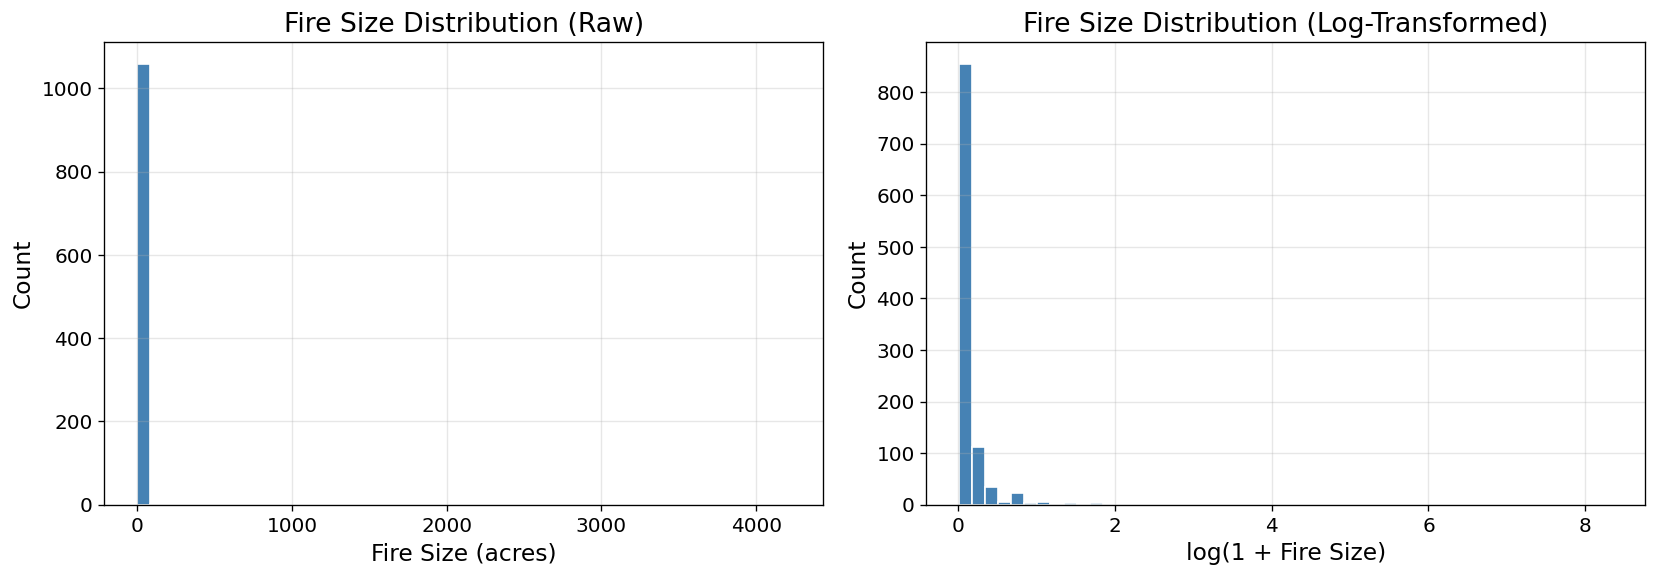

In [58]:
# Compare raw vs. log-transformed fire size distributions
# log1p = log(1+x) handles fires recorded with size 0 cleanly
fires['fire_size_log'] = np.log1p(fires['FIRE_SIZE'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
ax = axes[0]
ax.hist(fires['FIRE_SIZE'], bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Fire Size (acres)')
ax.set_ylabel('Count')
ax.set_title('Fire Size Distribution (Raw)')
ax.grid(True, alpha=0.3)

# Log-transformed
ax = axes[1]
ax.hist(fires['fire_size_log'], bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('log(1 + Fire Size)')
ax.set_ylabel('Count')
ax.set_title('Fire Size Distribution (Log-Transformed)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
# --- Step 4: Normalize features ---
# Geographic coordinates: Min-Max scale to [0, 1]
scaler_xy = MinMaxScaler()
xy_scaled = scaler_xy.fit_transform(fires[['LONGITUDE', 'LATITUDE']].values)

# Fire size (log): Min-Max scale to [0, 1]
scaler_size = MinMaxScaler()
fire_size_scaled = scaler_size.fit_transform(fires[['fire_size_log']].values)

# s is already in [0, 1]
# cause_binary is already 0 or 1

# Assemble feature matrix: [x_scaled, y_scaled, s, fire_size_scaled, cause_binary]
X = np.column_stack([
    xy_scaled,                          # columns 0, 1: geographic
    fires['s_param'].values,            # column 2: arc-length
    fire_size_scaled.ravel(),           # column 3: fire size (log + normalized)
    fires['cause_binary'].values        # column 4: cause type
])

# Feature names in order -- used downstream for plot labels and attribute indexing
feature_names = ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']

# This full feature matrix gets used in Tier 2.
# Tier 1 will use only X[:, :3] (geography + arc-length, no attributes)

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {feature_names}')
print(f'\nFirst 5 rows:')
print(np.array2string(X[:5], precision=4, suppress_small=True))

Feature matrix shape: (1068, 5)
Features: ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']

First 5 rows:
[[0.1654 0.3369 0.026  0.0102 1.    ]
 [0.5317 0.1934 0.8678 0.0102 1.    ]
 [0.3648 0.0065 0.9344 0.0256 0.    ]
 [0.2032 0.6204 0.1603 0.0102 1.    ]
 [0.5456 0.191  0.8635 0.0102 1.    ]]


In [60]:
# Save processed fire data as a CSV 
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

processed_path = processed_dir / 'tahoe_fires_processed.csv'
fires.to_csv(processed_path, index=False)

print(f'Saved {len(fires)} fires to {processed_path}')
print('Columns: LONGITUDE, LATITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,')
print('         FIRE_YEAR, DISCOVERY_DOY, cause_binary, t_param, s_param, fire_size_log')

Saved 1068 fires to ..\data\processed\tahoe_fires_processed.csv
Columns: LONGITUDE, LATITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,
         FIRE_YEAR, DISCOVERY_DOY, cause_binary, t_param, s_param, fire_size_log


## 5. Visualizing the Raw Data

Before clustering, we look at the spatial distribution of fires around the lake. The left panel colors each fire by cause (natural vs. human), and the right panel colors by arc-length position $s$ around the perimeter.

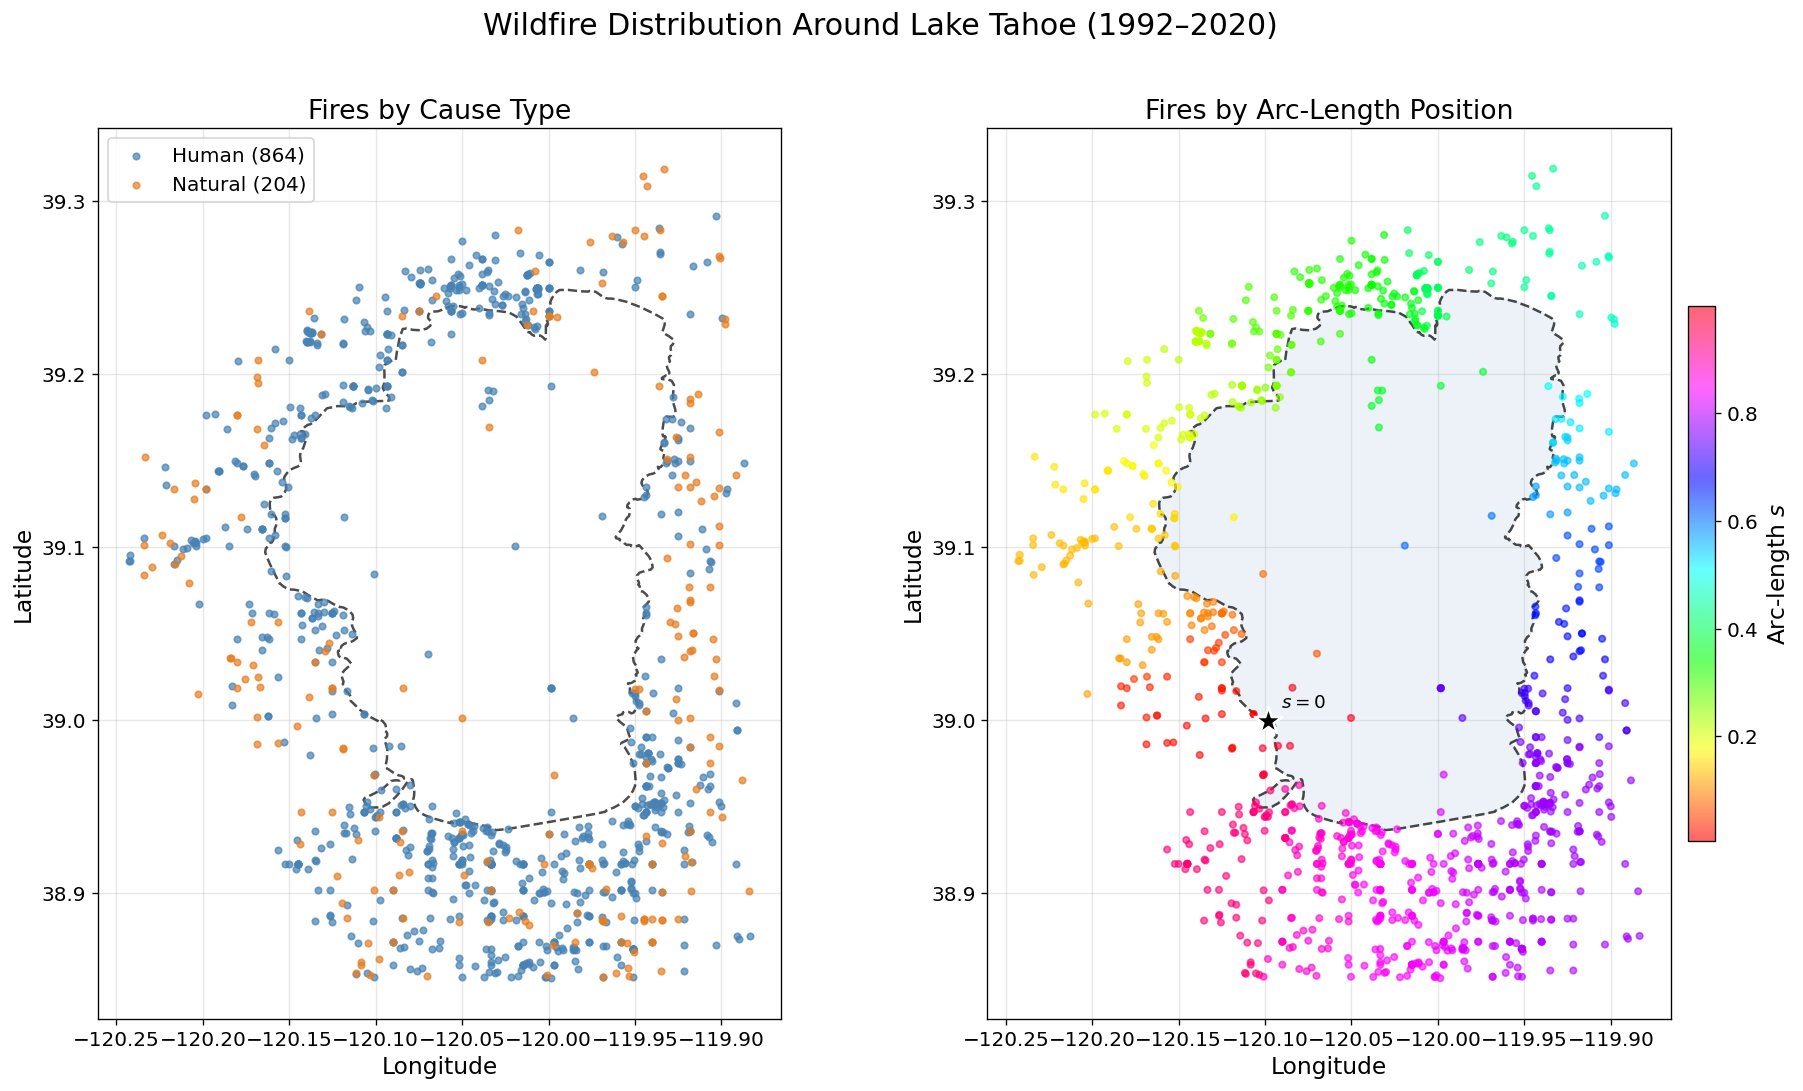

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# --- Left panel: by cause ---
ax = axes[0]
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0., color='steelblue')

natural = fires[fires['cause_binary'] == 0]
human = fires[fires['cause_binary'] == 1]

# Plot human first, natural on top 
ax.scatter(human['LONGITUDE'], human['LATITUDE'],
           c='steelblue', s=15, alpha=0.7, label=f'Human ({len(human)})', zorder=3)
ax.scatter(natural['LONGITUDE'], natural['LATITUDE'],
           c='#e67e22', s=15, alpha=0.7, label=f'Natural ({len(natural)})', zorder=3)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Fires by Cause Type')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# --- Right panel: by arc-length position ---
# HSV colormap wraps around so s=0 and s=1 show the same color
ax = axes[1]
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

scatter = ax.scatter(fires['LONGITUDE'], fires['LATITUDE'],
                     c=fires['s_param'], cmap='hsv', s=15, alpha=0.6, zorder=3)
plt.colorbar(scatter, ax=ax, label='Arc-length $s$', shrink=0.6, aspect=20, pad=0.02)

# Mark the boundary's start position (s = 0)
s0_xy = boundary.evaluate(boundary.t_range()[0])
ax.scatter(s0_xy[0], s0_xy[1], marker='*', s=300, color='black',
           edgecolors='white', linewidth=1.5, zorder=5)
ax.annotate('$s = 0$', xy=(s0_xy[0], s0_xy[1]), xytext=(8, 8),
            textcoords='offset points', fontsize=11, fontweight='bold')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Fires by Arc-Length Position')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

year_min = fires['FIRE_YEAR'].min()
year_max = fires['FIRE_YEAR'].max()
plt.suptitle(f'Wildfire Distribution Around Lake Tahoe ({year_min}–{year_max})', y=1.01)
plt.tight_layout()
plt.show()

---

# TIER 1: Spatial-Only Comparison

**Goal**: Isolate the effect of the arc-length parameter $s$ on clustering quality, without attributes.

In Tier 1, all methods use $\gamma = 0$ (no attribute component). The distance metric simplifies to:

$$d^2(\mathbf{x}, \mathbf{x}') = \alpha^2 \cdot \|\text{geo} - \text{geo}'\|^2 + \beta^2 \cdot d_s(s, s')^2$$

We compare two approaches:
1. **Standard k-Means** on $(x, y)$ -- baseline, ignoring the obstacle
2. **Obstacle-aware k-Means** on $(x, y, s)$ with $\alpha = \beta = 1$ -- equal spatial weights

A sensitivity check verifies that the choice of $\beta$ does not meaningfully change the clustering on this dataset.

## 6. Spatial-Only Feature Matrix

For Tier 1 we slice off the first three columns of the full feature matrix to build a spatial-only matrix `X_spatial`. The same matrix gets used in both the baseline standard k-Means and the obstacle-aware k-Means in this tier.

In [62]:
# Tier 1 uses only the spatial features (no attributes)
X_spatial = X[:, :3]

print(f'Tier 1 feature matrix shape: {X_spatial.shape}')
print(f'Features: {feature_names[:3]}')

Tier 1 feature matrix shape: (1068, 3)
Features: ['x_scaled', 'y_scaled', 's']


## 7. Choosing the Number of Clusters (elbow method)

Before running any clustering, we use the elbow method to choose $k$. The method runs k-Means for a range of $k$ values and plots the inertia (within-cluster sum of squared distances) for each. A good $k$ is where the curve bends; adding more clusters beyond that point gives diminishing returns.

We use standard k-Means here since the elbow method is about the data's natural cluster structure, not about the choice of distance metric.

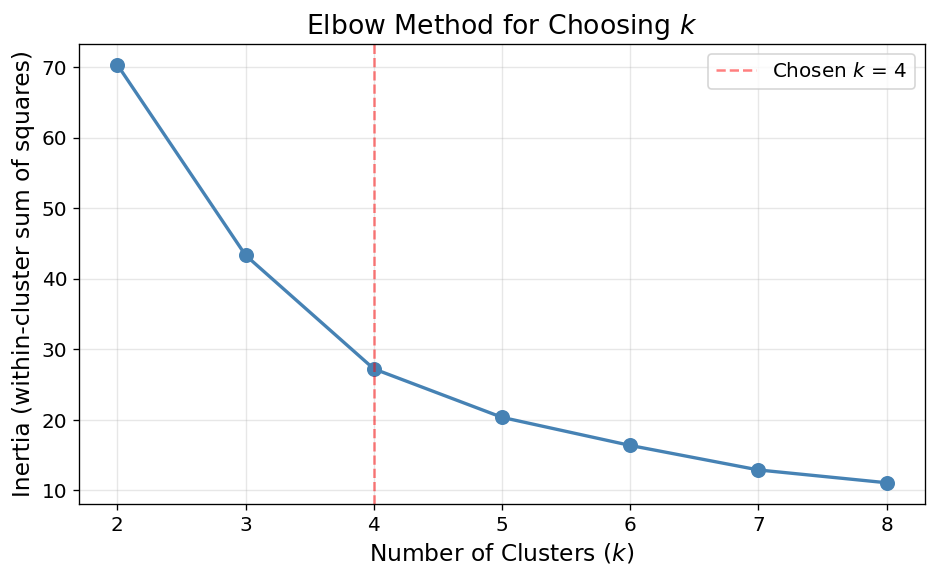

Inertia by k:
  k=2: 70.3290
  k=3: 43.3322
  k=4: 27.2352
  k=5: 20.3613
  k=6: 16.3810
  k=7: 12.9070
  k=8: 11.0922


In [63]:
# Elbow method: test k = 2 through 8
k_range = range(2, 9)
inertias = []

for k_test in k_range:
    km = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    km.fit(xy_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2, markersize=8)

# Mark the chosen k
ax.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Chosen $k$ = 4')

ax.set_xlabel('Number of Clusters ($k$)')
ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.set_title('Elbow Method for Choosing $k$')
ax.set_xticks(list(k_range))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the values for reference
print('Inertia by k:')
for k_test, inertia in zip(k_range, inertias):
    print(f'  k={k_test}: {inertia:.4f}')

The inertia curve flattens noticeably after $k = 4$, suggesting four clusters fit the spatial structure well. We use $k = 4$ throughout the rest of the notebook.

## 8. Standard k-Means Baseline

As a baseline, we run standard k-Means using only the geographic coordinates $(x, y)$. This treats the space as unobstructed and ignores fire attributes entirely. The result gives us a comparison point for the obstacle-aware version in Tier 1.

In [64]:
# Standard k-Means on (x, y) only
k = 4
kmeans_standard = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_standard = kmeans_standard.fit_predict(xy_scaled)

print(f'Standard k-Means converged in {kmeans_standard.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    n = np.sum(labels_standard == i)
    print(f'  Cluster {i+1}: {n} fires')

Standard k-Means converged in 10 iterations

Cluster sizes:
  Cluster 1: 305 fires
  Cluster 2: 230 fires
  Cluster 3: 223 fires
  Cluster 4: 310 fires


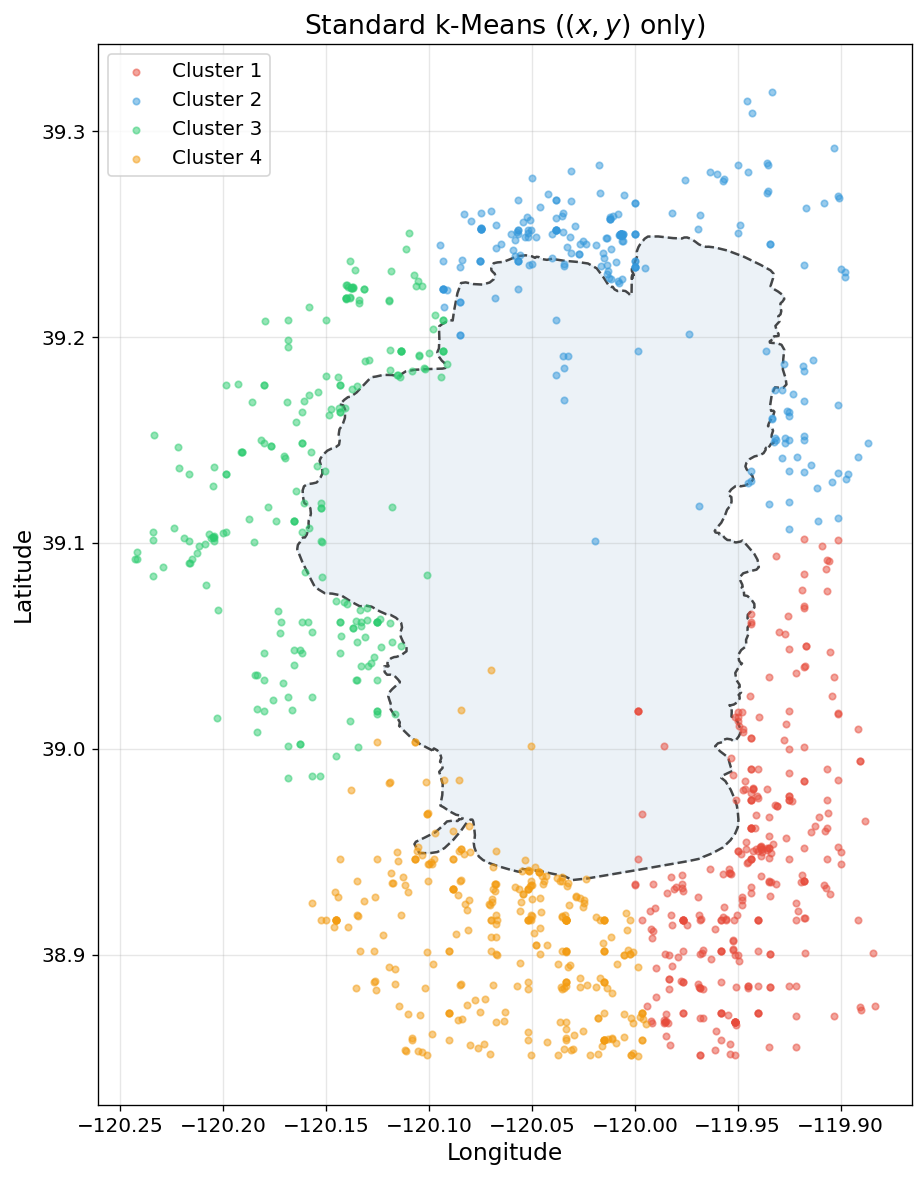

In [65]:
# Plot standard k-Means results
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(k):
    mask = labels_standard == i
    ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
               c=CLUSTER_COLORS[i], s=15, alpha=0.5, label=f'Cluster {i+1}', zorder=3)

ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Standard k-Means ($(x,y)$ only)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Obstacle-Aware k-Means 

We run the obstacle-aware algorithm with $\alpha = \beta = 1$, giving geographic distance and arc-length distance equal influence on cluster assignments. The next section examines whether varying $\beta$ changes the result, which informs whether tuning the balance matters for this dataset.

In [66]:
# Obstacle-aware k-Means: spatial only, equal weights (alpha = beta = 1)
model_t1_equal = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=0.0,    # no attributes
    random_state=42, n_attr=0
)
model_t1_equal.fit(X_spatial, t_data=fires['t_param'].values)
labels_t1_equal = model_t1_equal.labels_

print(f'Tier 1 equal weights: converged in {model_t1_equal.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t1_equal == i)} fires')

Tier 1 equal weights: converged in 13 iterations

Cluster sizes:
  Cluster 1: 305 fires
  Cluster 2: 236 fires
  Cluster 3: 216 fires
  Cluster 4: 311 fires


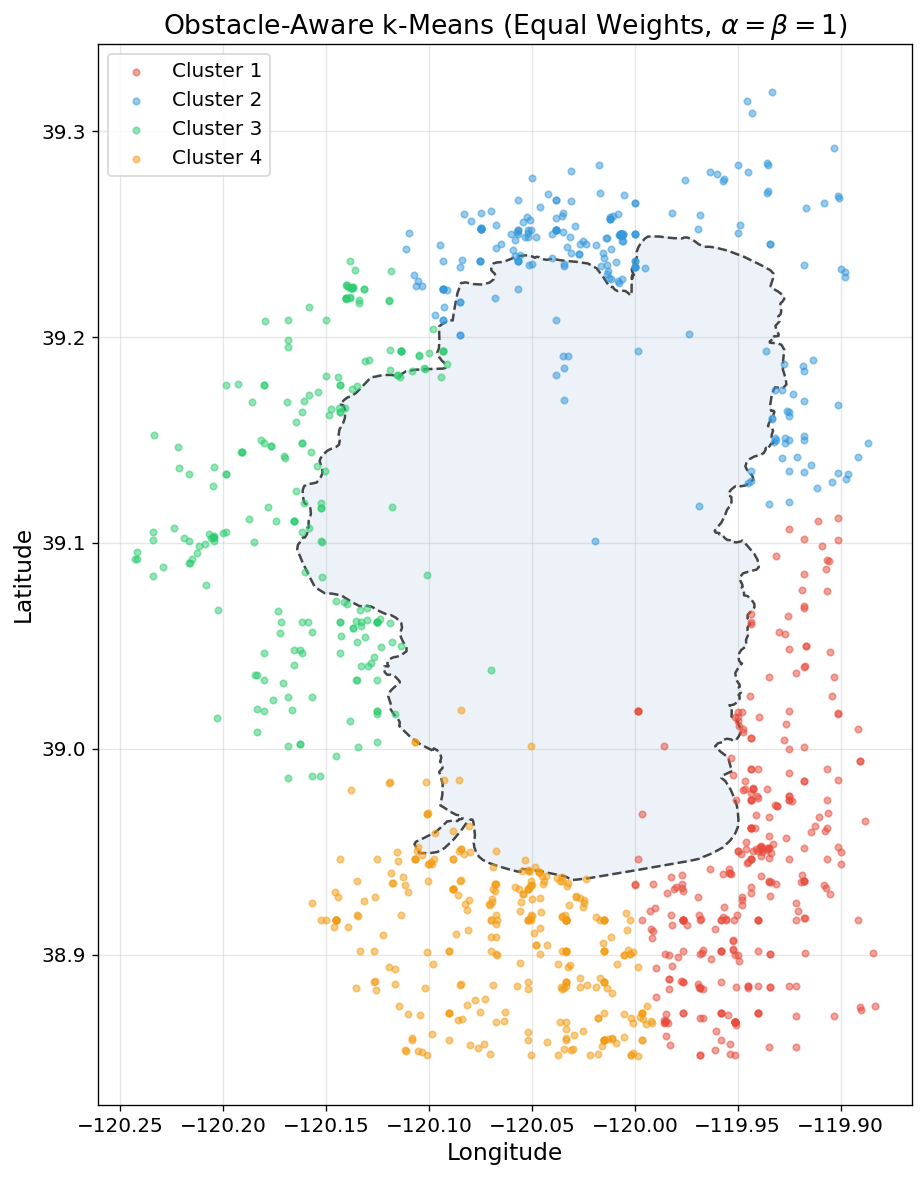

In [67]:
# Plot Tier 1 equal-weights clustering results
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(k):
    mask = labels_t1_equal == i
    ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
               c=CLUSTER_COLORS[i], s=15, alpha=0.5, label=f'Cluster {i+1}', zorder=3)

ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(r'Obstacle-Aware k-Means (Equal Weights, $\alpha = \beta = 1$)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Sensitivity to $\beta$

Before settling on $\beta = 1$, we check whether the choice of $\beta$ meaningfully changes the clustering. The objective function $J = \bar{\rho} + (1 - \sigma_a)$ simplifies in Tier 1 because there are no attribute features, so $\sigma_a = 0$ and $J$ reduces to the mean within-cluster distortion $\bar{\rho}$ -- a measure of how spread out the points are around their centroids. We calculate $J(\beta)$ across a grid of values and look at the spread.

In [68]:
# Compute J(beta) across a grid for the sensitivity curve 
def compute_tier1_beta_sweep():
    beta_grid = np.linspace(0.1, 2.0, 10)
    J_values = np.array([
        objective_function(
            (1.0, b, 0.0),
            X_spatial, fires['t_param'].values, boundary,
            k=k, n_attr=0, attr_indices=[], random_state=42
        )
        for b in beta_grid
    ])
    return beta_grid, J_values


beta_grid_t1, J_grid_t1 = cached_or_run(
    cache_dir / 'tier1_beta_sweep.pkl',
    compute_tier1_beta_sweep,
)

print('beta -> J:')
for b, j in zip(beta_grid_t1, J_grid_t1):
    print(f'  beta = {b:.2f}:  J = {j:.4f}')
print(f'\nRange: {J_grid_t1.max() - J_grid_t1.min():.4f}')

Loading cached: tier1_beta_sweep.pkl
beta -> J:
  beta = 0.10:  J = 1.0310
  beta = 0.31:  J = 1.0310
  beta = 0.52:  J = 1.0309
  beta = 0.73:  J = 1.0307
  beta = 0.94:  J = 1.0307
  beta = 1.16:  J = 1.0307
  beta = 1.37:  J = 1.0377
  beta = 1.58:  J = 1.0378
  beta = 1.79:  J = 1.0378
  beta = 2.00:  J = 1.0308

Range: 0.0070


$J$ varies by less than 1% across $\beta \in [0.1, 2.0]$. The choice of $\beta$ doesn't meaningfully change the clustering on this dataset. We use $\beta = 1$ for the comparison in the next section.

## 11. Tier 1 Comparison

We compare standard k-Means against obstacle-aware k-Means with $\beta = 1$. The side-by-side plot shows where the cluster boundaries differ; the quantitative comparison measures how well each method respects the lake.

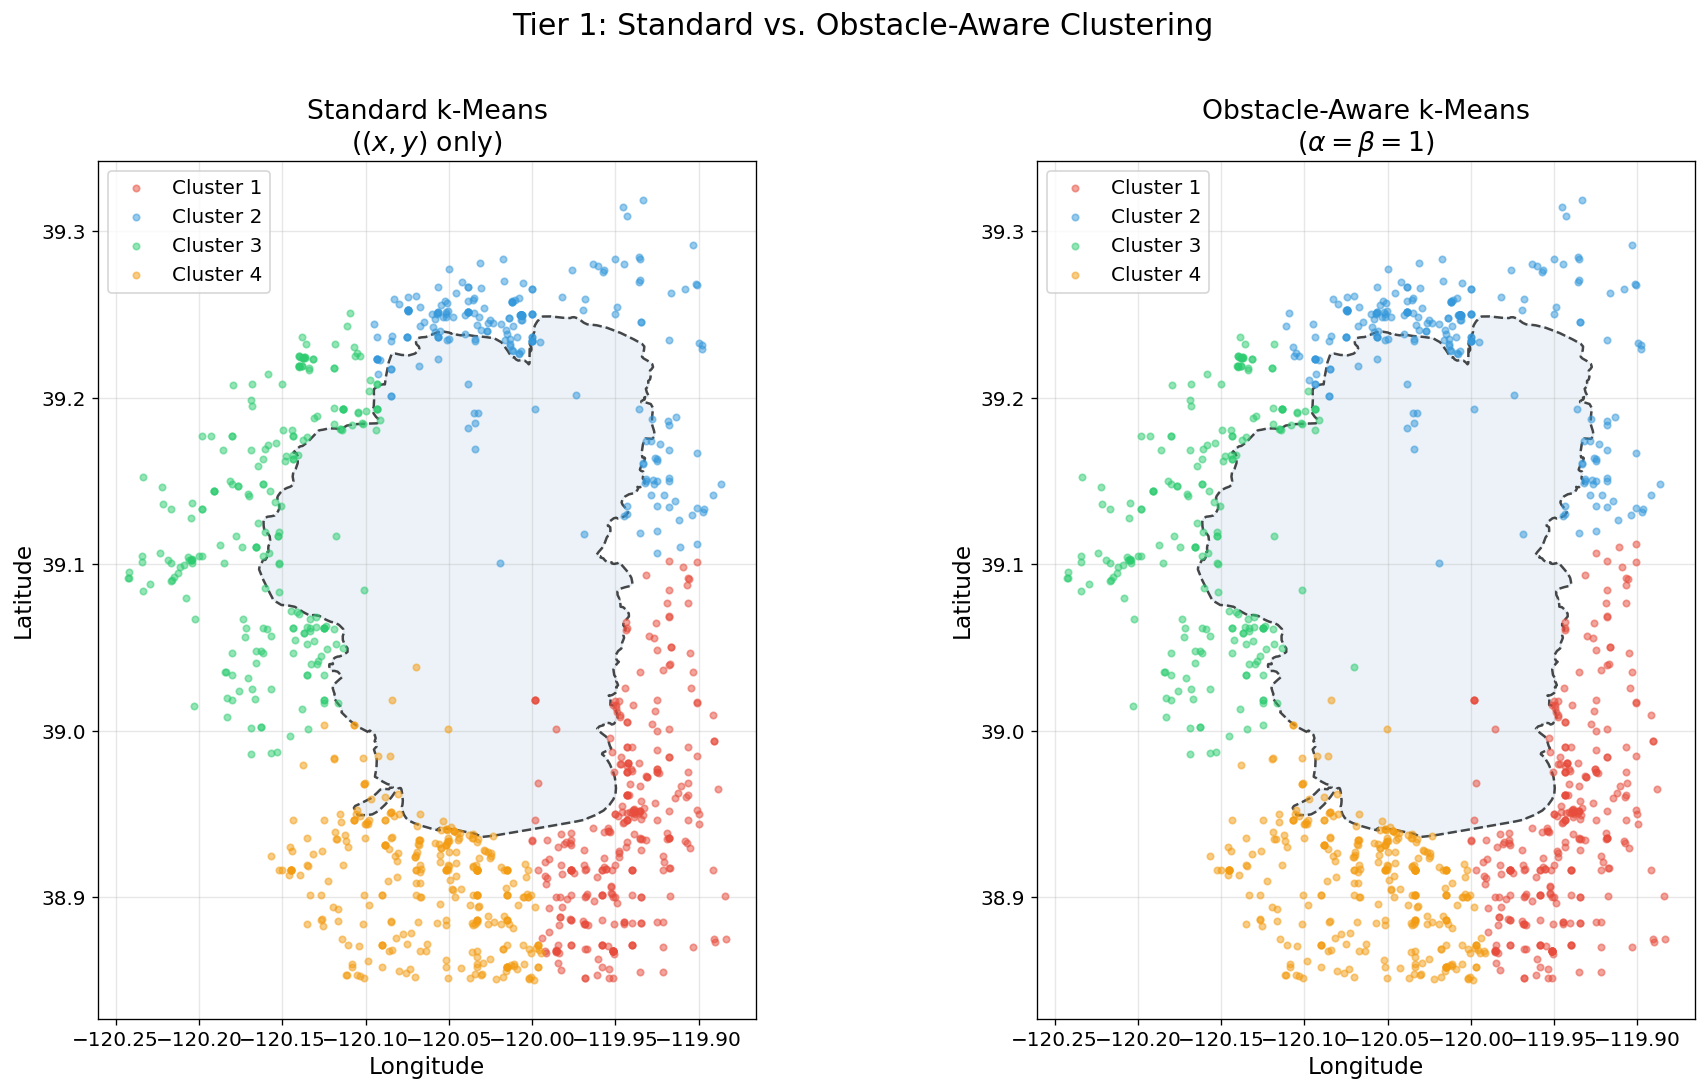

In [69]:
# Side-by-side: standard k-Means vs. obstacle-aware k-Means

# Map obstacle-aware cluster labels to standard k-Means labels
# so cluster colors stay consistent across the two panels
oa_to_std = map_labels_to_reference(labels_t1_equal, labels_standard, k)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

panel_data = [
    (labels_standard, lambda lbl: lbl, 'Standard k-Means\n($(x,y)$ only)'),
    (labels_t1_equal, lambda lbl: oa_to_std[lbl],
     r'Obstacle-Aware k-Means' + '\n' + r'($\alpha = \beta = 1$)'),
]

for ax, (labels, color_fn, title) in zip(axes, panel_data):
    # Boundary first
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
            linewidth=1.5, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')
    # Fires
    for cluster_id in range(k):
        mask = labels == cluster_id
        ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
                   c=CLUSTER_COLORS[color_fn(cluster_id)], s=15, alpha=0.5,
                   label=f'Cluster {color_fn(cluster_id)+1}', zorder=3)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    ax.legend()
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Tier 1: Standard vs. Obstacle-Aware Clustering', y=1.01)
plt.tight_layout()
plt.show()

### Quantitative Comparison

We measure how well each method respects the lake boundary using **mean arc-length span** -- the average, across clusters, of the smallest arc on the boundary that contains all of that cluster's projected fire locations. A lower span means each cluster's fires sit on a more compact stretch of shoreline.

In [70]:
def arc_length_span(s_values):
    """Smallest arc on [0,1] that contains all s values (handles wraparound)."""
    if len(s_values) <= 1:
        return 0.0
    s_sorted = np.sort(s_values % 1.0)
    gaps = np.diff(s_sorted)
    wrap_gap = (1.0 - s_sorted[-1]) + s_sorted[0]
    all_gaps = np.append(gaps, wrap_gap)
    return 1.0 - np.max(all_gaps)


# Reuse oa_to_std mapping for cluster labels
methods = [
    ('Standard k-Means', labels_standard, lambda lbl: lbl),
    ('Obstacle-Aware (β = 1)', labels_t1_equal, lambda lbl: oa_to_std[lbl]),
]

rows = []
for name, labels, color_fn in methods:
    spans_by_mapped_id = {}
    for raw_cluster_id in range(k):
        mapped_id = color_fn(raw_cluster_id)
        spans_by_mapped_id[mapped_id] = arc_length_span(
            fires['s_param'].values[labels == raw_cluster_id]
        )
    row = {f'Cluster {c+1}': spans_by_mapped_id[c] for c in range(k)}
    row['Mean'] = np.mean(list(spans_by_mapped_id.values()))
    row['Method'] = name
    rows.append(row)

comparison_t1 = pd.DataFrame(rows).set_index('Method')

# Render as a styled table 
styled_t1 = (
    comparison_t1.style
    .format('{:.4f}')
    .set_caption('Tier 1: Arc-length span by cluster')
    .set_table_styles([
        {'selector': 'caption',
         'props': 'caption-side: top; font-size: 1.1em; font-weight: bold; padding: 8px;'},
        {'selector': 'th',
         'props': 'background-color: #f0f0f0; padding: 6px 12px; text-align: center;'},
        {'selector': 'td',
         'props': 'padding: 6px 12px; text-align: right;'},
        {'selector': 'th.row_heading',
         'props': 'text-align: left;'},
    ])
    .highlight_min(subset=['Mean'], color='#e8f5e9')
)

styled_t1

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Mean
Method,,,,,
Standard k-Means,0.1977,0.3536,0.2754,0.2331,0.2650
Obstacle-Aware (β = 1),0.1965,0.3361,0.2725,0.1850,0.2475


The obstacle-aware method tightens the mean arc-length span from 0.265 to 0.247 -- a small 7% reduction. Most of the improvement comes from Cluster 4 (0.233 → 0.185). Clusters 1 and 3 are nearly unchanged, consistent with the visual comparison: standard k-Means already separates most fires reasonably well based on geography alone, and the arc-length parameter only reshapes assignments at a few cluster boundaries.

This is consistent with the sensitivity analysis in the previous section: $\beta$ doesn't change the clustering much because most fires are far enough from the lake that geographic distance and arc-length distance largely agree on cluster assignments. The obstacle-aware algorithm produces a slightly tighter clustering, but the effect is small for this dataset.

---

# TIER 2: Adding Attributes

**Goal**: Show that the framework extends to incorporate fire attributes (size and cause), creating clusters that are both spatially coherent and behaviorally distinct.

In Tier 2, the full distance metric is used:

$$d^2(\mathbf{x}, \mathbf{x}') = \alpha^2 \cdot \|\text{geo} - \text{geo}'\|^2 + \beta^2 \cdot d_s(s, s')^2 + \gamma^2 \cdot \|\text{attr} - \text{attr}'\|^2$$

The objective function $J = \bar{\rho} + (1 - \sigma_a)$ now includes the attribute separation $\sigma_a$, which measures whether clusters differ significantly in fire size and cause type.

We compare three methods to disentangle what each component of the framework contributes:

1. **Standard k-Means** on $(x, y, \text{fire size}, \text{cause})$ -- the reference point, with sklearn's default behavior (no weight tuning).
2. **Optimized k-Means without $s$** -- the same feature set, but with $\gamma$ tuned by grid search. This isolates the contribution of optimizing attribute weight without involving arc-length.
3. **Optimized obstacle-aware k-Means** -- adds $s$ to the feature set and tunes $(\beta, \gamma)$ jointly. The full framework.

### Optimization Strategy

We use grid search to find optimal weights -- 15 values of $\gamma$ for the no-$s$ method (1D), and a 15×15 grid of $(\beta, \gamma)$ values for the obstacle-aware method (2D). The $\alpha$ weight is fixed at 1 since only the ratios between weights affect cluster assignments.

We constrain $\gamma \in [0, 1]$ so that $\gamma \leq \alpha$, which keeps attributes from outweighing spatial structure in the clustering. Without this constraint, the optimizer pushes $\gamma$ much higher than $\alpha$ to maximize attribute separation, at the expense of geographic coherence.

## 12. Three Methods


### 12.1 Standard k-Means

The first method is sklearn's standard k-Means on $(x, y, \text{fire size}, \text{cause})$ -- geographic coordinates plus attributes, with no arc-length component and no weight tuning. This is the reference point against which the two optimized methods get compared.

In [71]:
# Standard k-Means baseline for Tier 2: (x, y, fire_size, cause) -- no s, no tuning
# We slice off column 2 (s) from the full feature matrix
X_t2_std = np.column_stack([
    X[:, :2],       # x, y
    X[:, 3:],       # fire_size, cause
])

kmeans_t2_std = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_t2_std = kmeans_t2_std.fit_predict(X_t2_std)

print(f'Standard k-Means: converged in {kmeans_t2_std.n_iter_} iterations')
print('\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t2_std == i)} fires')

# Calculate attribute separation for the comparison table
sigma_t2_std, _ = attribute_separation(X, labels_t2_std, k, attr_indices=[3, 4])

Standard k-Means: converged in 6 iterations

Cluster sizes:
  Cluster 1: 184 fires
  Cluster 2: 204 fires
  Cluster 3: 491 fires
  Cluster 4: 189 fires


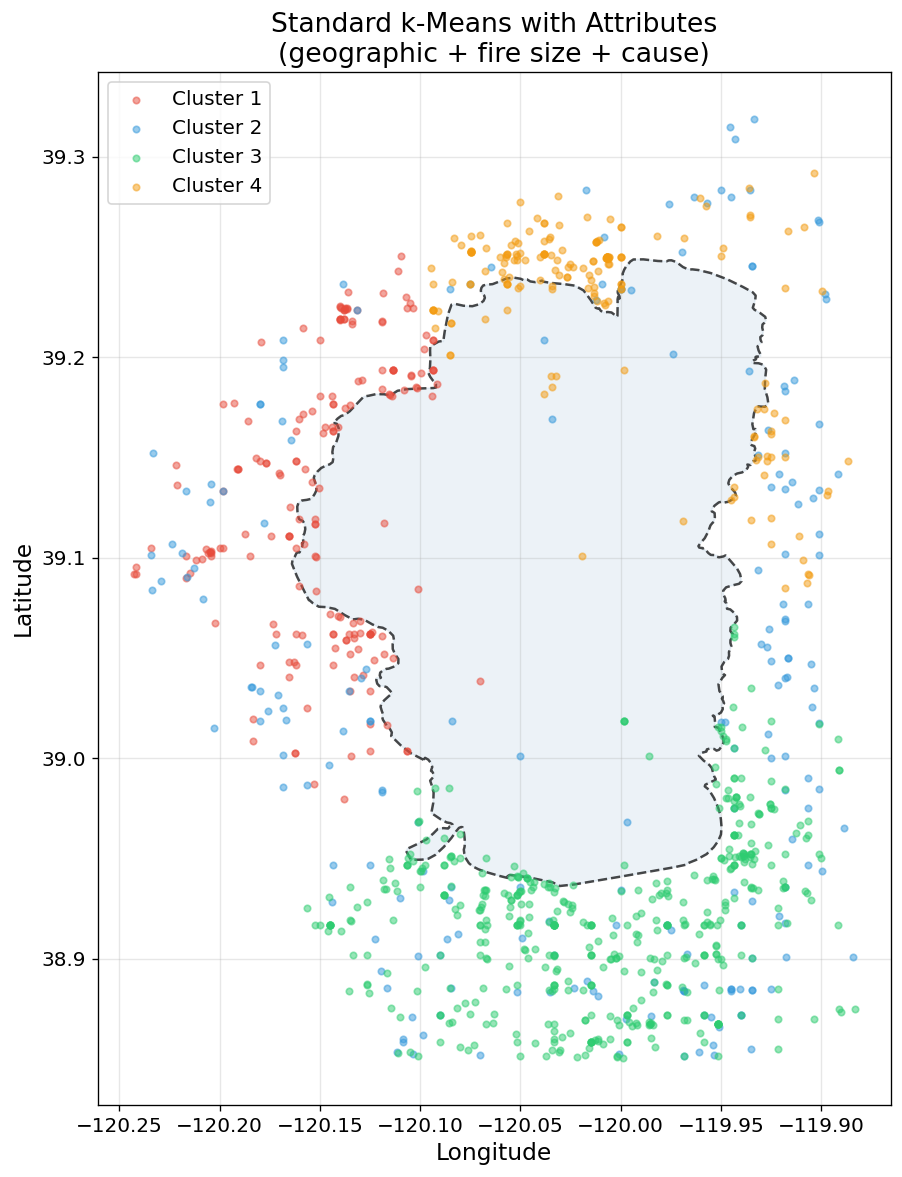

In [72]:
# Plot Tier 2 standard k-Means results
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(k):
    mask = labels_t2_std == i
    ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
               c=CLUSTER_COLORS[i], s=15, alpha=0.5, label=f'Cluster {i+1}', zorder=3)

ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Standard k-Means with Attributes\n(geographic + fire size + cause)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 13.2 Optimized k-Means without $s$

The second method uses the same features as standard k-Means $(x, y, \text{fire size}, \text{cause})$, but tunes the weight on attributes with a grid search. Comparing this against standard k-Means (Section 13.1) isolates the contribution of weight optimization. Comparing it against the obstacle-aware method (Section 13.3) isolates the contribution of $s$.

We use the obstacle-aware framework with $\beta = 0$ (no $s$) and search for the best $\gamma \in [0.05, 1.0]$ over a 1D grid of 15 values. The $\alpha$ weight stays fixed at 1.

In [73]:
# 1D grid search: optimize gamma with no s (beta = 0)
def compute_no_s_grid_search():
    print('Computing optimized-no-s grid search (1D over gamma)...')
    n_grid = 15
    gamma_vals = np.linspace(0.05, 1.0, n_grid)

    J_grid = np.zeros(n_grid)
    for j, g in enumerate(gamma_vals):
        J_grid[j] = objective_function(
            (1.0, 0.0, g),
            X, fires['t_param'].values, boundary,
            k=k, n_attr=2, attr_indices=[3, 4], random_state=42
        )
    return gamma_vals, J_grid


gamma_grid_no_s, J_grid_no_s = cached_or_run(
    cache_dir / 'tier2_no_s_grid_search.pkl',
    compute_no_s_grid_search,
)

# Find the grid minimum
opt_gamma_no_s = gamma_grid_no_s[np.argmin(J_grid_no_s)]
opt_J_no_s = J_grid_no_s.min()

# Refit the model at the optimum
model_t2_no_s = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=0.0, gamma=opt_gamma_no_s,
    random_state=42, n_attr=2
)
model_t2_no_s.fit(X, t_data=fires['t_param'].values)
labels_t2_no_s = model_t2_no_s.labels_

# Calculate attribute separation for the comparison table
sigma_t2_no_s, _ = attribute_separation(X, labels_t2_no_s, k, attr_indices=[3, 4])

print(f'\nOptimal gamma: {opt_gamma_no_s:.4f}')
print(f'Optimal J:     {opt_J_no_s:.4f}')
print('\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t2_no_s == i)} fires')

Loading cached: tier2_no_s_grid_search.pkl

Optimal gamma: 0.3893
Optimal J:     0.5418

Cluster sizes:
  Cluster 1: 508 fires
  Cluster 2: 115 fires
  Cluster 3: 222 fires
  Cluster 4: 223 fires


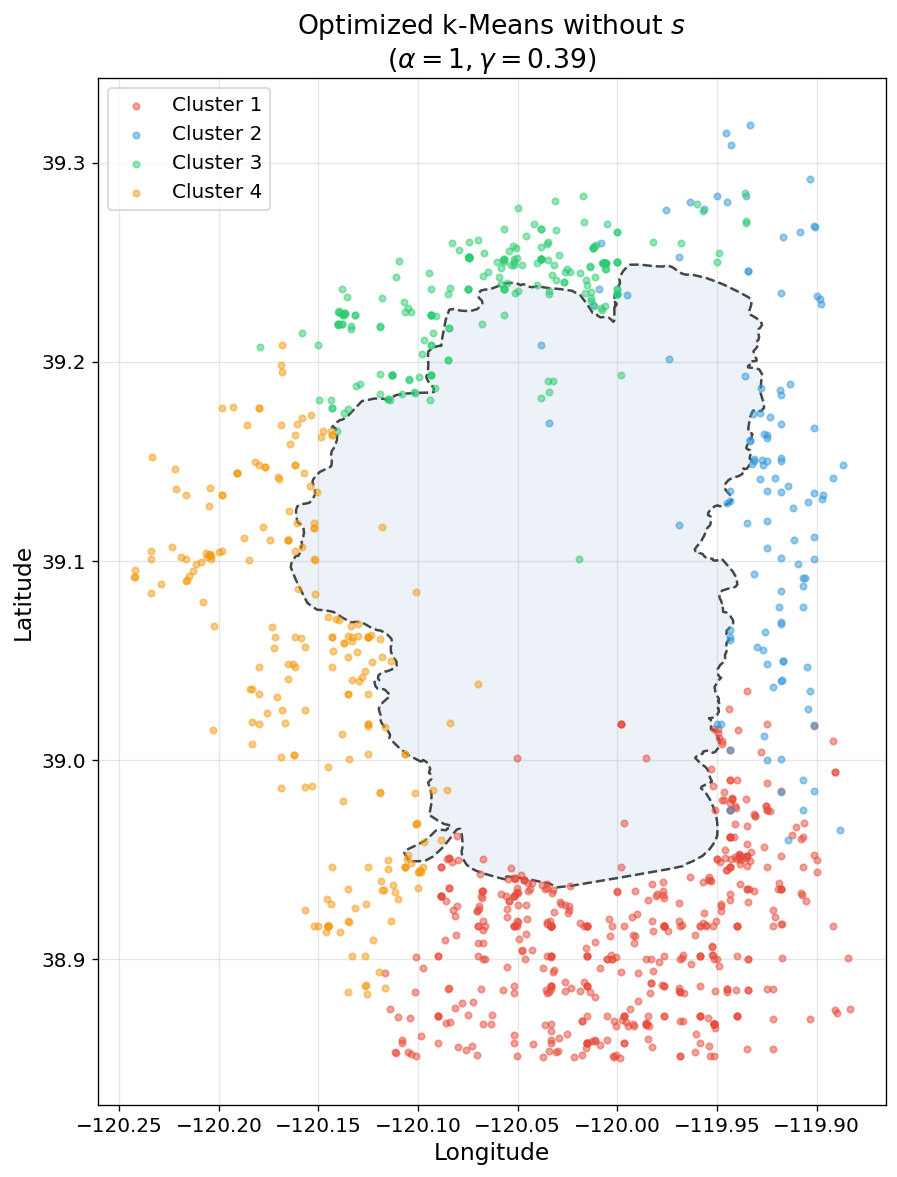

In [74]:
# Plot optimized-no-s clustering results
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(k):
    mask = labels_t2_no_s == i
    ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
               c=CLUSTER_COLORS[i], s=15, alpha=0.5, label=f'Cluster {i+1}', zorder=3)

ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(r'Optimized k-Means without $s$' + '\n' +
             rf'($\alpha = 1, \gamma = {opt_gamma_no_s:.2f}$)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 13.3 Optimized Obstacle-Aware k-Means

The third method adds the arc-length parameter $s$ to the feature set and tunes both $\beta$ and $\gamma$ by grid search. This is the full obstacle-aware framework. Comparing it against Section 13.2's no-$s$ method isolates the contribution of $s$.

We search for the best $(\beta, \gamma)$ over a 15×15 grid, with $\beta \in [0.05, 2.0]$ and $\gamma \in [0.05, 1.0]$. The $\alpha$ weight stays fixed at 1.


**Note**: The first run takes around 30-60 minutes. Subsequent runs load the cached result instantly.

In [75]:
# Compute J across a grid of (beta, gamma) and select the minimum
def compute_tier2_grid_search():
    print('Computing Tier 2 objective surface and finding grid minimum...')
    n_grid = 15
    beta_vals = np.linspace(0.05, 2.0, n_grid)
    gamma_vals = np.linspace(0.05, 1.0, n_grid)

    J_grid = np.zeros((n_grid, n_grid))
    for i, b in enumerate(beta_vals):
        for j, g in enumerate(gamma_vals):
            J_grid[i, j] = objective_function(
                (1.0, b, g),
                X, fires['t_param'].values, boundary,
                k=k, n_attr=2, attr_indices=[3, 4], random_state=42
            )
        print(f'  beta row {i+1}/{n_grid} complete')
    return beta_vals, gamma_vals, J_grid


beta_grid_t2, gamma_grid_t2, J_surface_t2 = cached_or_run(
    cache_dir / 'tier2_grid_search.pkl',
    compute_tier2_grid_search,
)

# Find minimum on the grid
i_min, j_min = np.unravel_index(J_surface_t2.argmin(), J_surface_t2.shape)
opt_beta_t2 = beta_grid_t2[i_min]
opt_gamma_t2 = gamma_grid_t2[j_min]
opt_J_t2 = J_surface_t2[i_min, j_min]

# Refit the model at the optimum
model_t2_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=opt_beta_t2, gamma=opt_gamma_t2,
    random_state=42, n_attr=2
)
model_t2_opt.fit(X, t_data=fires['t_param'].values)
labels_t2_opt = model_t2_opt.labels_

# Calculate attribute separation for the comparison table
sigma_t2_opt, _ = attribute_separation(X, labels_t2_opt, k, attr_indices=[3, 4])

print(f'\nOptimal beta:  {opt_beta_t2:.4f}')
print(f'Optimal gamma: {opt_gamma_t2:.4f}')
print(f'Optimal J:     {opt_J_t2:.4f}')
print('\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_t2_opt == i)} fires')

Loading cached: tier2_grid_search.pkl

Optimal beta:  0.4679
Optimal gamma: 0.3893
Optimal J:     0.4589

Cluster sizes:
  Cluster 1: 485 fires
  Cluster 2: 119 fires
  Cluster 3: 233 fires
  Cluster 4: 231 fires


### Validating the Optimum

We plot the objective surface as a contour map to confirm that the grid optimum sits at a meaningful minimum.

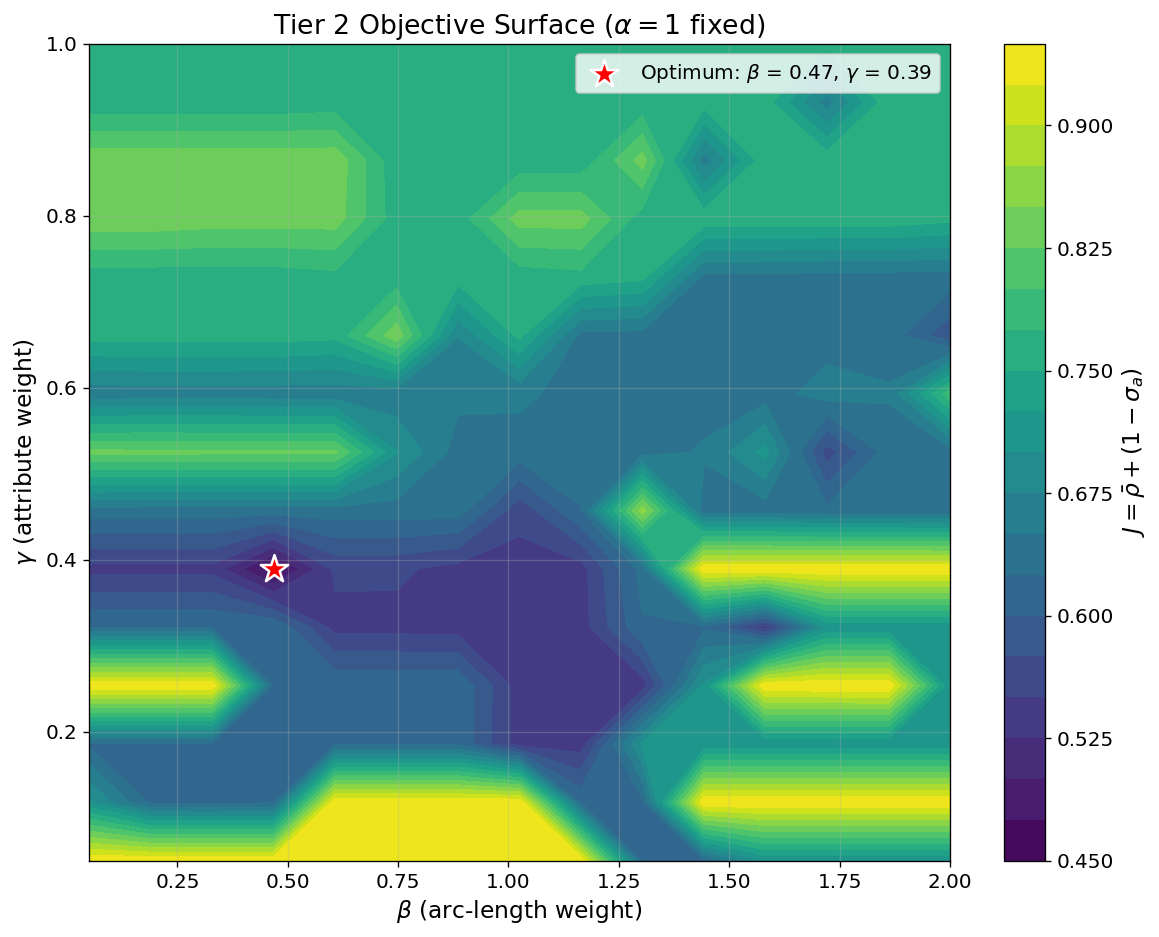

In [76]:
# Contour plot of the objective surface with the optimum marked
fig, ax = plt.subplots(figsize=(10, 8))

# Build a meshgrid for plotting (note: indexing='ij' matches our J_grid layout)
B, G = np.meshgrid(beta_grid_t2, gamma_grid_t2, indexing='ij')

# Filled contours
contour_filled = ax.contourf(B, G, J_surface_t2, levels=20, cmap='viridis')
plt.colorbar(contour_filled, ax=ax, label=r'$J = \bar{\rho} + (1 - \sigma_a)$')

# Optimum
ax.scatter(opt_beta_t2, opt_gamma_t2, marker='*', s=300, color='red',
           edgecolors='white', linewidth=1.5, zorder=5,
           label=f'Optimum: $\\beta$ = {opt_beta_t2:.2f}, $\\gamma$ = {opt_gamma_t2:.2f}')

ax.set_xlabel(r'$\beta$ (arc-length weight)')
ax.set_ylabel(r'$\gamma$ (attribute weight)')
ax.set_title(r'Tier 2 Objective Surface ($\alpha = 1$ fixed)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The objective surface shows a broad low-$J$ valley centered around $\gamma \approx 0.35$, with the grid optimum at $(\beta = 0.47, \gamma = 0.39)$ sitting inside this valley. Extreme attribute weights (very low or very high $\gamma$) produce worse clusterings, confirming that attributes help but shouldn't overwhelm the spatial structure.

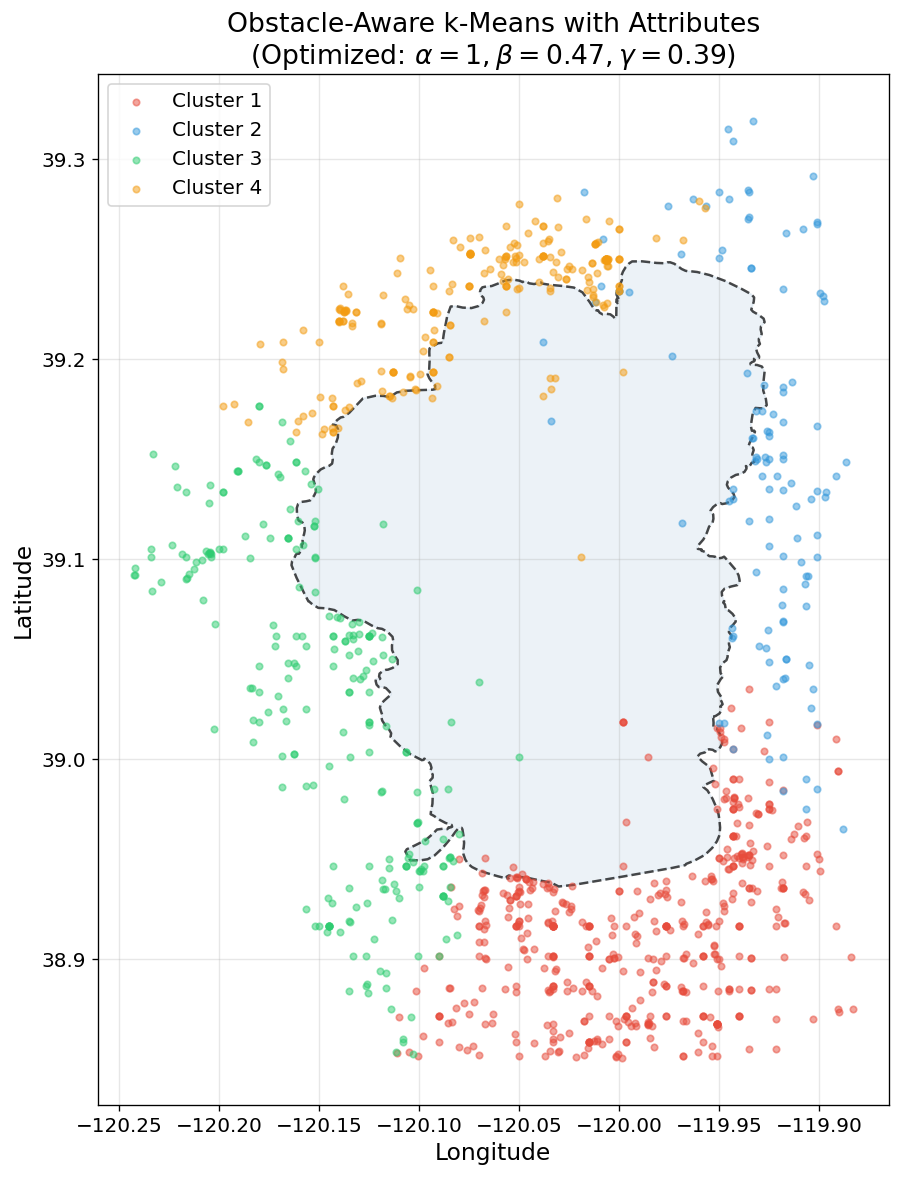

In [77]:
# Plot Tier 2 obstacle-aware clustering results
fig, ax = plt.subplots(figsize=(10, 10))

for i in range(k):
    mask = labels_t2_opt == i
    ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
               c=CLUSTER_COLORS[i], s=15, alpha=0.5, label=f'Cluster {i+1}', zorder=3)

ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(r'Obstacle-Aware k-Means with Attributes' + '\n' +
             rf'(Optimized: $\alpha = 1, \beta = {opt_beta_t2:.2f}, \gamma = {opt_gamma_t2:.2f}$)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Cluster Profiles

We summarize each cluster's spatial center and attribute composition. The table below gives the centroid location, fire size statistics, and cause breakdown for the four optimized clusters.

In [78]:
# Build a profile table for the optimized clusters
fires['cluster_t2_opt'] = labels_t2_opt

profile_rows = []
for c in range(k):
    cluster = fires[fires['cluster_t2_opt'] == c]
    n = len(cluster)
    n_natural = int((cluster['cause_binary'] == 0).sum())
    n_human = n - n_natural
    profile_rows.append({
        'Cluster': c + 1,
        'n': n,
        'Centroid (lon, lat)': f'({cluster["LONGITUDE"].mean():.3f}, {cluster["LATITUDE"].mean():.3f})',
        'Mean fire size (acres)': cluster['FIRE_SIZE'].mean(),
        'Median fire size (acres)': cluster['FIRE_SIZE'].median(),
        '% Natural': 100 * n_natural / n,
        '% Human': 100 * n_human / n,
    })

profile_t2 = pd.DataFrame(profile_rows).set_index('Cluster')

# Render as a styled table
styled_profile = (
    profile_t2.style
    .format({
        'Mean fire size (acres)': '{:.2f}',
        'Median fire size (acres)': '{:.2f}',
        '% Natural': '{:.1f}',
        '% Human': '{:.1f}',
    })
    .set_caption('Tier 2 Optimized Clusters: Profile Summary')
    .set_table_styles([
        {'selector': 'caption',
         'props': 'caption-side: top; font-size: 1.1em; font-weight: bold; padding: 8px;'},
        {'selector': 'th',
         'props': 'background-color: #f0f0f0; padding: 6px 12px; text-align: center;'},
        {'selector': 'td',
         'props': 'padding: 6px 12px; text-align: right;'},
        {'selector': 'th.row_heading',
         'props': 'text-align: center;'},
    ])
)

styled_profile

,n,"Centroid (lon, lat)",Mean fire size (acres),Median fire size (acres),% Natural,% Human
Cluster,,,,,,
1,485,"(-119.991, 38.914)",8.22,0.10,12.2,87.8
2,119,"(-119.930, 39.147)",52.42,0.10,62.2,37.8
3,233,"(-120.147, 39.023)",2.14,0.10,27.0,73.0
4,231,"(-120.069, 39.228)",1.60,0.10,3.5,96.5


The four optimized clusters represent distinct fire regimes:

- **Cluster 1 (south basin)** is the largest cluster, dominated by human-caused fires (87.8%) of moderate average size.
- **Cluster 2 (east-central)** is the smallest but most distinctive cluster: the only one where natural causes are the majority (62.2%), with mean fire size more than six times larger than any other cluster. This likely captures lightning-strike fires in less-developed terrain that grow before suppression.
- **Cluster 3 (west shore)** has the most mixed cause distribution (27% natural) and small mean fire size.
- **Cluster 4 (north basin)** is overwhelmingly human-caused (96.5%), with the smallest mean fire size.

The persistent 0.10-acre median across all clusters reflects the long tail of small reported fires in the FPA FOD database; the differences between clusters show up in the means, where the influence of larger fires is captured.

## 14. Comparing the Three Methods

We compare the three methods on two metrics: **mean arc-length span** (geographic coherence) and $\boldsymbol{\sigma_a}$ (attribute separation). Because each method differs from the next by a single change, the differences in metric values can be attributed to specific changes:

- Standard k-Means → Optimized without $s$: the contribution of weight optimization
- Optimized without $s$ → Optimized obstacle-aware: the contribution of $s$
- Standard k-Means → Optimized obstacle-aware: the combined contribution of both

### 14.1 Visual Comparison

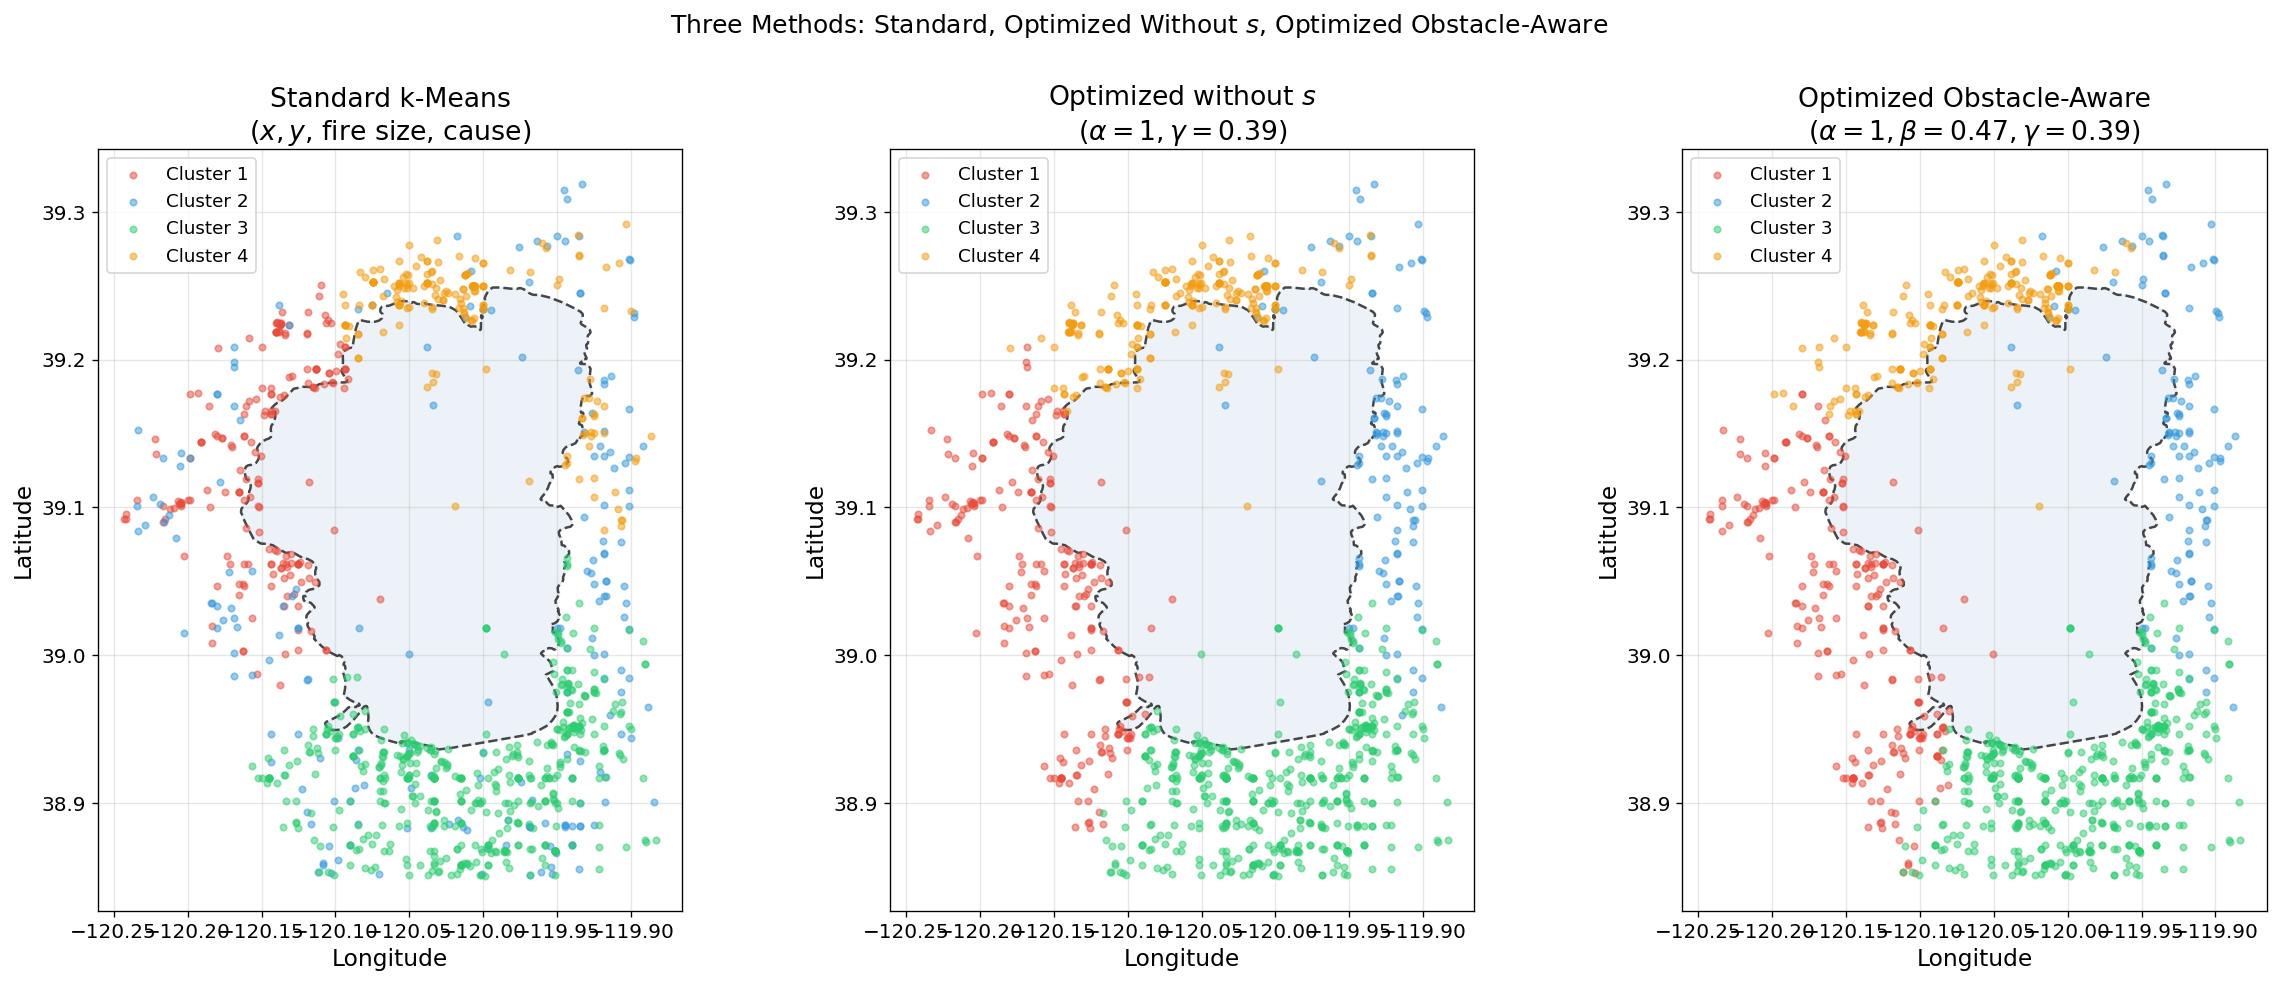

In [79]:
# Side-by-side: standard, optimized without s, optimized obstacle-aware

# Map the two optimized label sets to standard k-Means' labels
# so cluster colors stay consistent across the three panels
no_s_to_std = map_labels_to_reference(labels_t2_no_s, labels_t2_std, k)
opt_to_std = map_labels_to_reference(labels_t2_opt, labels_t2_std, k)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

panel_data = [
    (labels_t2_std, lambda lbl: lbl,
     'Standard k-Means\n($x, y$, fire size, cause)'),
    (labels_t2_no_s, lambda lbl: no_s_to_std[lbl],
     r'Optimized without $s$' + '\n' +
     rf'($\alpha = 1, \gamma = {opt_gamma_no_s:.2f}$)'),
    (labels_t2_opt, lambda lbl: opt_to_std[lbl],
     r'Optimized Obstacle-Aware' + '\n' +
     rf'($\alpha = 1, \beta = {opt_beta_t2:.2f}, \gamma = {opt_gamma_t2:.2f}$)'),
]

for ax, (labels, color_fn, title) in zip(axes, panel_data):
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
            linewidth=1.5, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

    raw_for_mapped = {color_fn(raw): raw for raw in range(k)}
    for mapped_id in range(k):
        raw_id = raw_for_mapped[mapped_id]
        mask = labels == raw_id
        ax.scatter(fires['LONGITUDE'].values[mask], fires['LATITUDE'].values[mask],
                   c=CLUSTER_COLORS[mapped_id], s=15, alpha=0.5,
                   label=f'Cluster {mapped_id + 1}', zorder=3)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    ax.legend(fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Three Methods: Standard, Optimized Without $s$, Optimized Obstacle-Aware',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 14.2 Quantitative Comparison

We measure each method using two metrics:

- **Mean arc-length span** -- the average, across clusters, of the smallest arc on the boundary that contains all of that cluster's projected fire locations. Smaller values indicate clusters that sit on more compact stretches of shoreline.

- **Attribute separation $\boldsymbol{\sigma_a}$** -- the fraction of pairwise cluster-vs-cluster attribute differences that are statistically significant. For each attribute (fire size and cause), we run a Kruskal-Wallis omnibus test across all $k$ clusters, then Dunn's post-hoc test on each pair of clusters with Bonferroni correction. With $k = 4$ and two attributes, there are 12 pairwise tests total; $\sigma_a$ is the fraction of those that find a significant difference.

Both metrics are calculated on the cluster labels using the same formula regardless of how the labels were produced, which makes them directly comparable across methods.

In [80]:
# Compare mean arc-length span and σ_a across the three methods
methods_t2 = [
    ('Standard k-Means', labels_t2_std, sigma_t2_std),
    (r'Optimized without $s$', labels_t2_no_s, sigma_t2_no_s),
    ('Optimized Obstacle-Aware', labels_t2_opt, sigma_t2_opt),
]

rows = []
for name, labels, sigma_a in methods_t2:
    spans = [
        arc_length_span(fires['s_param'].values[labels == c])
        for c in range(k)
    ]
    rows.append({
        'Method': name,
        'Mean arc-length span': np.mean(spans),
        'σ_a': sigma_a,
    })

comparison_t2 = pd.DataFrame(rows).set_index('Method')

styled_t2 = (
    comparison_t2.style
    .format('{:.4f}')
    .set_caption('Tier 2: Comparison across three methods')
    .set_table_styles([
        {'selector': 'caption',
         'props': 'caption-side: top; font-size: 1.1em; font-weight: bold; padding: 8px;'},
        {'selector': 'th',
         'props': 'background-color: #f0f0f0; padding: 6px 12px; text-align: center;'},
        {'selector': 'td',
         'props': 'padding: 6px 12px; text-align: right;'},
        {'selector': 'th.row_heading',
         'props': 'text-align: left;'},
    ])
    .highlight_min(subset=['Mean arc-length span'], color='#e8f5e9')
    .highlight_max(subset=['σ_a'], color='#e8f5e9')
)

styled_t2

,Mean arc-length span,σ_a
Method,,
Standard k-Means,0.4739,0.2500
Optimized without $s$,0.3585,0.5000
Optimized Obstacle-Aware,0.3513,0.5833


The three rows let us read off what each component of the framework contributes:

- **Standard k-Means → Optimized without $s$** measures what weight optimization adds. Mean span drops from 0.474 to 0.359 (a 24% improvement), and $\sigma_a$ doubles from 0.250 to 0.500. Optimization is doing most of the work here -- tuning $\gamma$ alone produces clusters that are both noticeably tighter geographically and substantially more attribute-distinct than sklearn's defaults.

- **Optimized without $s$ → Optimized Obstacle-Aware** measures what $s$ adds on top of optimization. Mean span drops slightly from 0.359 to 0.351 (a 2% improvement), and $\sigma_a$ improves from 0.500 to 0.583 (a 17% improvement). On the basin-wide dataset, $s$ adds a modest improvement, mostly visible in attribute separation.

- **Standard k-Means → Optimized Obstacle-Aware** is the combined effect: a 26% reduction in mean span and a 133% increase in $\sigma_a$ over standard k-Means.

Most of the improvement in our two metrics comes from optimization, not from $s$ itself.  This is consistent with Tier 1, where $s$ also produced only a small improvement in isolation. Section 15 asks whether $s$ contributes more on a subset where it has the most positional information to offer -- fires close to the lake.

### 14.3 Interpreting $\sigma_a$

 With $k = 4$ clusters and 2 attributes, there are $\binom{4}{2} \times 2 = 12$ pairwise tests total. σ_a is the fraction that find a significant difference at $p < 0.05$ after Bonferroni correction -- a conservative adjustment that multiplies each $p$-value by the number of pairwise tests within an attribute, controlling the chance of false positives across multiple comparisons. The minimum non-zero value of σ_a is $1/12 \approx 0.0833$.

To establish the by-chance floor, we calculate σ_a on the Tier 1 cluster labels -- which were formed without using attributes at all.

In [81]:
# Calculate σ_a on Tier 1 cluster labels — what attribute separation 
# emerges by chance from purely geographic clustering?
sigma_t1_std, _ = attribute_separation(
    X, labels_standard, k, attr_indices=[3, 4]
)
sigma_t1_oa, _ = attribute_separation(
    X, labels_t1_equal, k, attr_indices=[3, 4]
)

baseline_rows = [
    {'Method': 'Tier 1 standard k-Means (no attributes used)',     'σ_a': sigma_t1_std},
    {'Method': 'Tier 1 obstacle-aware (β = 1, no attributes used)', 'σ_a': sigma_t1_oa},
    {'Method': 'Tier 2 standard k-Means',                           'σ_a': sigma_t2_std},
    {'Method': 'Tier 2 optimized without $s$',                      'σ_a': sigma_t2_no_s},
    {'Method': 'Tier 2 optimized obstacle-aware',                   'σ_a': sigma_t2_opt},
]

baseline_t2 = pd.DataFrame(baseline_rows).set_index('Method')

styled_baseline = (
    baseline_t2.style
    .format('{:.4f}')
    .set_caption('Attribute separation across all methods')
    .set_table_styles([
        {'selector': 'caption',
         'props': 'caption-side: top; font-size: 1.1em; font-weight: bold; padding: 8px;'},
        {'selector': 'th',
         'props': 'background-color: #f0f0f0; padding: 6px 12px; text-align: center;'},
        {'selector': 'td',
         'props': 'padding: 6px 12px; text-align: right;'},
        {'selector': 'th.row_heading',
         'props': 'text-align: left;'},
    ])
    .highlight_max(subset=['σ_a'], color='#e8f5e9')
)

styled_baseline

,σ_a
Method,
Tier 1 standard k-Means (no attributes used),0.0833
"Tier 1 obstacle-aware (β = 1, no attributes used)",0.0833
Tier 2 standard k-Means,0.2500
Tier 2 optimized without $s$,0.5000
Tier 2 optimized obstacle-aware,0.5833


Both Tier 1 methods sit at the floor (σ_a = 0.0833), confirming that very little attribute separation emerges by chance from purely geographic clustering. Tier 2 standard k-Means raises σ_a to 0.2500, optimizing $\gamma$ pushes it to 0.5000, and adding optimized $s$ brings it to 0.5833 -- about seven times the by-chance baseline. 

To see what σ_a = 0.5833 means concretely, the diagnostic below identifies which specific cluster pairs differ on which attributes for the optimized clustering.

In [82]:
# Diagnostic: which pairwise differences are significant for the optimized clustering (13.3)?

attr_names = ['fire_size', 'cause_binary']
attr_indices = [3, 4]
n_sig_total = 0

print('Significant pairwise differences for the optimized obstacle-aware clustering:\n')
for attr_name, attr_idx in zip(attr_names, attr_indices):
    print(f'Attribute: {attr_name}')
    
    # Build a DataFrame of attribute values per cluster
    attr_data = pd.DataFrame({
        'value': X[:, attr_idx],
        'cluster': labels_t2_opt + 1  # 1-indexed for display
    })
    
    # Kruskal-Wallis omnibus test
    groups = [attr_data[attr_data['cluster'] == c]['value'].values for c in range(1, k+1)]
    h_stat, h_p = kruskal(*groups)
    print(f'  Omnibus Kruskal-Wallis: H = {h_stat:.2f}, p = {h_p:.4f}')
    
    # Pairwise Dunn's test with Bonferroni correction
    dunn = posthoc_dunn(attr_data, val_col='value', group_col='cluster', p_adjust='bonferroni')
    
    # Print which pairs are significant at p < 0.05
    n_sig = 0
    for i in range(1, k+1):
        for j in range(i+1, k+1):
            p = dunn.loc[i, j]
            sig = '✓' if p < 0.05 else ' '
            if p < 0.05: n_sig += 1
            print(f'    Cluster {i} vs Cluster {j}: p = {p:.4f}  {sig}')
    print(f'  Significant pairs: {n_sig}/6\n')
    n_sig_total += n_sig

print('σ_a = (total significant pairs) / (total pairs across attributes)')
print(f'    = {n_sig_total} / 12 = {sigma_t2_opt:.4f}')

Significant pairwise differences for the optimized obstacle-aware clustering:

Attribute: fire_size
  Omnibus Kruskal-Wallis: H = 8.75, p = 0.0328
    Cluster 1 vs Cluster 2: p = 1.0000   
    Cluster 1 vs Cluster 3: p = 1.0000   
    Cluster 1 vs Cluster 4: p = 0.3102   
    Cluster 2 vs Cluster 3: p = 1.0000   
    Cluster 2 vs Cluster 4: p = 0.2190   
    Cluster 3 vs Cluster 4: p = 0.0339  ✓
  Significant pairs: 1/6

Attribute: cause_binary
  Omnibus Kruskal-Wallis: H = 203.91, p = 0.0000
    Cluster 1 vs Cluster 2: p = 0.0000  ✓
    Cluster 1 vs Cluster 3: p = 0.0000  ✓
    Cluster 1 vs Cluster 4: p = 0.0339  ✓
    Cluster 2 vs Cluster 3: p = 0.0000  ✓
    Cluster 2 vs Cluster 4: p = 0.0000  ✓
    Cluster 3 vs Cluster 4: p = 0.0000  ✓
  Significant pairs: 6/6

σ_a = (total significant pairs) / (total pairs across attributes)
    = 7 / 12 = 0.5833


**Cause type drives most of the separation.** All 6 cluster pairs differ significantly on cause type, with most $p$-values below $0.0001$. This reflects how strongly fire cause correlates with location at Lake Tahoe -- human-caused fires concentrate near population centers and recreation areas, while natural ignitions cluster in the east-central backcountry.

**Fire size separates only one cluster pair.** The omnibus test on fire size is significant ($H = 8.75, p = 0.033$), but only Cluster 3 vs. Cluster 4 shows significance after Bonferroni correction at the pair level. 


This is the basin-wide picture: the framework adds value, optimization does most of the work, and σ_a is driven mostly by cause type. But "basin-wide" averages over fires that sit far from the lake. The next section restricts the analysis to fires close to the obstacle, where the arc-length parameter $s$ should carry more information.

## 15. Does $s$ Matter More for Fires Close to the Lake?

The basin-wide comparison showed that $s$ contributes only a small additional improvement once attributes are optimized. One possible explanation: many fires in the basin aren't close enough to the lake for $s$ to carry meaningful positional information. The median fire is 2.4 km from shore, and roughly half the fires are more than 3 km away. At those distances, the projection only tells us which side of the lake a fire is on, not exactly where -- which means $s$ ends up being more noise than signal.

To test this, we restrict the analysis to fires within 2 km of the lake shore (468 fires, about 44% of the basin total) and rerun the optimization on this subset. If $s$ carries more information for near-shore fires, we should see a larger contribution from $s$ on the restricted dataset.

### Filtering to the Near-Shore Subset

In [83]:
# Calculate each fire's straight-line distance to its boundary projection
distances_to_lake_km = np.zeros(len(fires))
for i, t in enumerate(fires['t_param'].values):
    proj = boundary.evaluate(t)
    lon_diff = fires['LONGITUDE'].iloc[i] - proj[0]
    lat_diff = fires['LATITUDE'].iloc[i] - proj[1]
    # Approximate degrees to km at lat 39 (1 deg lat ≈ 111 km, 1 deg lon ≈ 87 km)
    distances_to_lake_km[i] = np.sqrt((lon_diff * 87)**2 + (lat_diff * 111)**2)

fires['dist_to_lake_km'] = distances_to_lake_km

# Filter to fires within 2 km of shore
threshold_km = 2
near_mask = fires['dist_to_lake_km'].values < threshold_km
n_near = near_mask.sum()
print(f'Near-shore subset: fires within {threshold_km} km '
      f'({n_near}/{len(fires)} fires, {100*n_near/len(fires):.1f}%)')

# Subset the feature matrix and the s/t arrays
X_near = X[near_mask]
t_near = fires['t_param'].values[near_mask]
s_near = fires['s_param'].values[near_mask]

Near-shore subset: fires within 2 km (468/1068 fires, 43.8%)


### Re-Optimizing Weights for the Subset

Optimal weights tuned on the full basin may not be the right balance for fires concentrated near the obstacle. We re-run the 15×15 grid search on the near-shore subset to find weights that work for this regime.

In [88]:
# Grid search on the near-shore subset
def compute_near_shore_grid_search():
    print('Computing near-shore objective surface (15x15 grid)...')
    n_grid = 15
    beta_vals = np.linspace(0.05, 2.0, n_grid)
    gamma_vals = np.linspace(0.05, 1.0, n_grid)

    J_grid = np.zeros((n_grid, n_grid))
    for i, b in enumerate(beta_vals):
        for j, g in enumerate(gamma_vals):
            J_grid[i, j] = objective_function(
                (1.0, b, g),
                X_near, t_near, boundary,
                k=k, n_attr=2, attr_indices=[3, 4], random_state=42
            )
        print(f'  beta row {i+1}/{n_grid} complete')
    return beta_vals, gamma_vals, J_grid


beta_grid_near, gamma_grid_near, J_surface_near = cached_or_run(
    cache_dir / 'near_shore_grid_search.pkl',
    compute_near_shore_grid_search,
)

# Find the grid minimum
i_min, j_min = np.unravel_index(J_surface_near.argmin(), J_surface_near.shape)
opt_beta_near = beta_grid_near[i_min]
opt_gamma_near = gamma_grid_near[j_min]
opt_J_near = J_surface_near[i_min, j_min]

# Refit with optimized near-shore weights, with s on
model_near_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=opt_beta_near, gamma=opt_gamma_near,
    random_state=42, n_attr=2
)
model_near_opt.fit(X_near, t_data=t_near)
spans_near_opt = [
    arc_length_span(s_near[model_near_opt.labels_ == c])
    for c in range(k)
]
sigma_near_opt, _ = attribute_separation(
    X_near, model_near_opt.labels_, k, attr_indices=[3, 4]
)

# Refit at the same gamma but with β = 0 (s off), to isolate s's contribution
model_near_no_s_reopt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=0.0, gamma=opt_gamma_near,
    random_state=42, n_attr=2
)
model_near_no_s_reopt.fit(X_near, t_data=t_near)
spans_near_no_s_reopt = [
    arc_length_span(s_near[model_near_no_s_reopt.labels_ == c])
    for c in range(k)
]
sigma_near_no_s_reopt, _ = attribute_separation(
    X_near, model_near_no_s_reopt.labels_, k, attr_indices=[3, 4]
)

print(f'\nNear-shore optimal weights: β = {opt_beta_near:.4f}, γ = {opt_gamma_near:.4f}')
print(f'Optimal J: {opt_J_near:.4f}')
print(f'\nWith re-optimized weights:')
print(f'  With s (β = {opt_beta_near:.2f}):  '
      f'span = {np.mean(spans_near_opt):.4f}, σ_a = {sigma_near_opt:.4f}')
print(f'  Without s (β = 0):       '
      f'span = {np.mean(spans_near_no_s_reopt):.4f}, σ_a = {sigma_near_no_s_reopt:.4f}')

span_pct_reopt = (
    100 * (np.mean(spans_near_no_s_reopt) - np.mean(spans_near_opt))
    / np.mean(spans_near_no_s_reopt)
)
sigma_pct_reopt = (
    100 * (sigma_near_opt - sigma_near_no_s_reopt) / sigma_near_no_s_reopt
    if sigma_near_no_s_reopt > 0 else float('inf')
)
print(f'\n  s contribution to span:   {span_pct_reopt:+.1f}%')
print(f'  s contribution to σ_a:    {sigma_pct_reopt:+.1f}%')

Loading cached: near_shore_grid_search.pkl

Near-shore optimal weights: β = 0.8857, γ = 0.5929
Optimal J: 0.6179

With re-optimized weights:
  With s (β = 0.89):  span = 0.3395, σ_a = 0.4167
  Without s (β = 0):       span = 0.4612, σ_a = 0.2500

  s contribution to span:   +26.4%
  s contribution to σ_a:    +66.7%


### Comparing $s$'s Contribution at Each Scale

The bar chart below directly compares how much $s$ contributes on the full basin (where most fires are far from the lake) versus on the near-shore subset (where $s$ carries the most positional information).

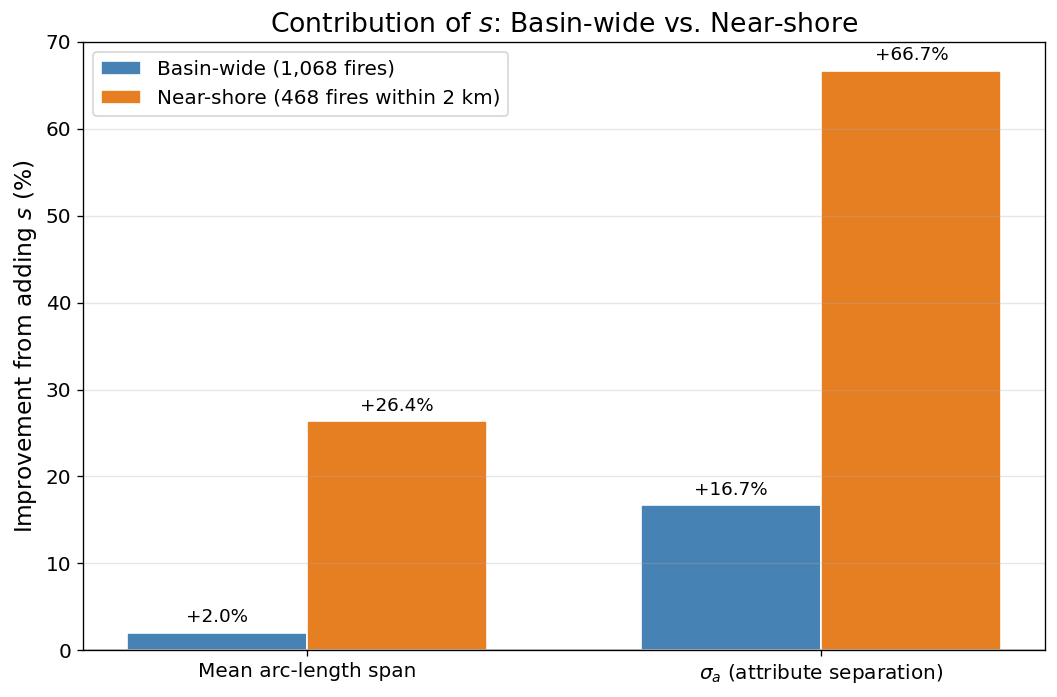

In [86]:
# Comparison bar chart: s contribution at the basin level vs. near-shore
fig, ax = plt.subplots(figsize=(9, 6))

# Calculate basin-wide s contribution from the comparison table
# (Optimized obstacle-aware vs. Optimized without s)
span_basin_no_s = comparison_t2.loc['Optimized without $s$', 'Mean arc-length span']
span_basin_opt = comparison_t2.loc['Optimized Obstacle-Aware', 'Mean arc-length span']
sigma_basin_no_s = comparison_t2.loc['Optimized without $s$', 'σ_a']
sigma_basin_opt = comparison_t2.loc['Optimized Obstacle-Aware', 'σ_a']

basin_span_pct = 100 * (span_basin_no_s - span_basin_opt) / span_basin_no_s
basin_sigma_pct = 100 * (sigma_basin_opt - sigma_basin_no_s) / sigma_basin_no_s

metrics = ['Mean arc-length span', r'$\sigma_a$ (attribute separation)']
basin_pcts = [basin_span_pct, basin_sigma_pct]
near_shore_pcts = [span_pct_reopt, sigma_pct_reopt]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, basin_pcts, width,
               label=f'Basin-wide ({len(fires):,} fires)',
               color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, near_shore_pcts, width,
               label=f'Near-shore ({n_near} fires within {threshold_km:.0f} km)',
               color='#e67e22', edgecolor='white')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:+.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=11)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Improvement from adding $s$ (%)')
ax.set_title('Contribution of $s$: Basin-wide vs. Near-shore')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

On the near-shore subset (468 fires within 2 km of the lake), the optimal weights are $\beta = 0.89$ and $\gamma = 0.59$ -- both higher than the basin-wide optimum, reflecting that fires near the obstacle reward stronger weighting on both $s$ and attributes. Adding $s$ to this configuration improves the mean span by 26.4% (from 0.461 to 0.340) and $\sigma_a$ by 66.7% (from 0.250 to 0.417).

These results are an order of magnitude larger than the basin-wide contribution of $s$ (2% span improvement, 17% $\sigma_a$ improvement), confirming that $s$ contributes substantially when applied to fires near the obstacle. The basin-wide result was diluted because most fires aren't close enough to the lake for $s$ to carry meaningful positional information. The improvement in $\sigma_a$ is indirect -- $s$ doesn't carry attribute information directly, but tightening clusters geographically also tightens them in attribute space, since fire causes in the basin have some correlation with location.

The implication: the algorithm's effectiveness scales with the fraction of points actually situated near the obstacle.

### Near-Shore Optimized Clustering
Now we can observe the optimized clustering plot and profiles of these fires within 2km of the lake.

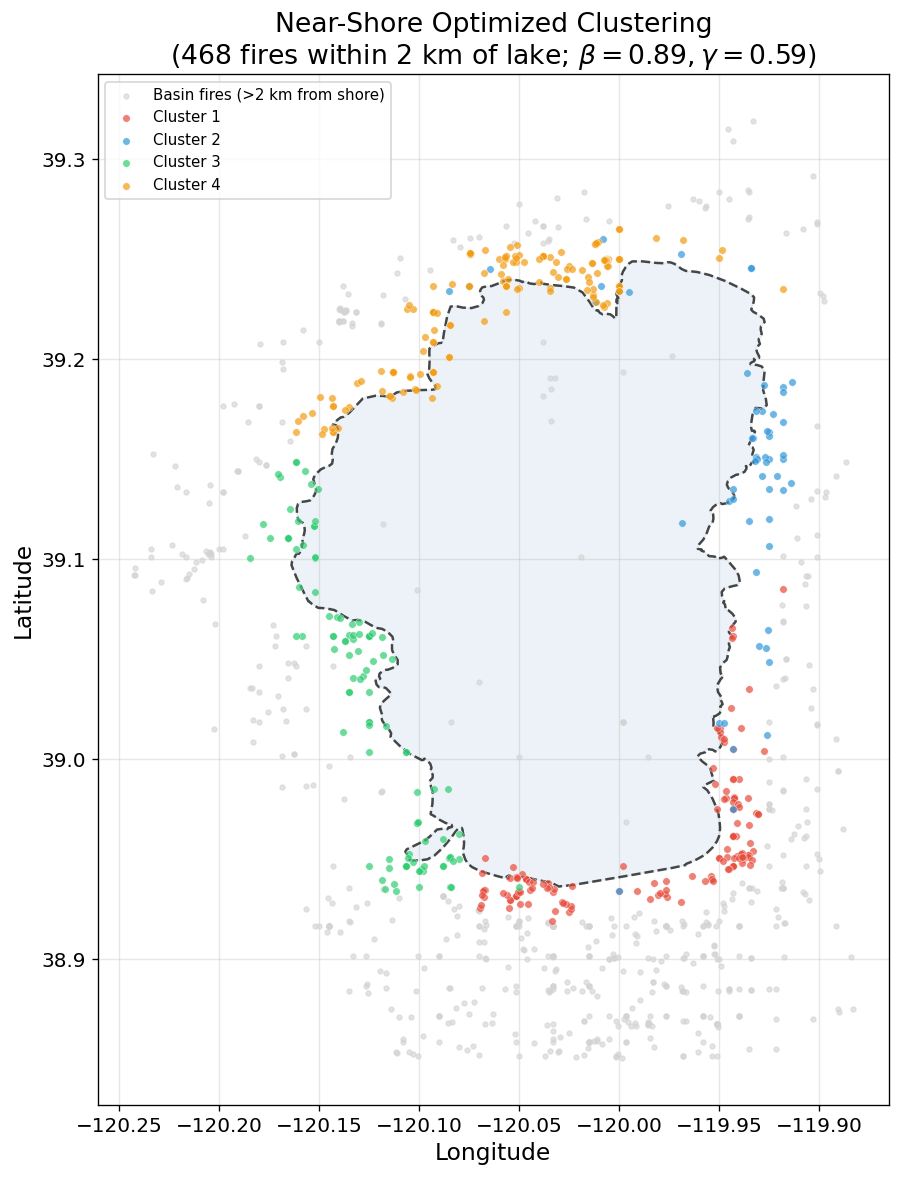

In [94]:
# Reference labels: the basin cluster for each near-shore fire
ref_labels_near = fires.loc[near_mask, 'cluster_t2_opt'].to_numpy()

# Build the mapping: near-shore label -> basin label that overlaps it most
near_to_basin = map_labels_to_reference(
    model_near_opt.labels_, ref_labels_near, k
)

# Apply the mapping to get aligned labels
labels_near_aligned = np.array([near_to_basin[l] for l in model_near_opt.labels_])

# Plot near-shore optimized clustering for the writeup
fig, ax = plt.subplots(figsize=(10, 10))

# Boundary first
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

# Show all basin fires faintly for context
basin_mask = ~near_mask
ax.scatter(fires['LONGITUDE'].values[basin_mask],
           fires['LATITUDE'].values[basin_mask],
           c='lightgray', s=8, alpha=0.6, zorder=2,
           label=f'Basin fires (>2 km from shore)')

# Align near-shore labels to the basin reference so colors match across plots
ref_labels_near = fires.loc[near_mask, 'cluster_t2_opt'].to_numpy()
near_to_basin = map_labels_to_reference(
    model_near_opt.labels_, ref_labels_near, k
)
labels_near_aligned = np.array([near_to_basin[l] for l in model_near_opt.labels_])

# Near-shore fires colored by cluster (using aligned labels)
fires_near = fires[near_mask].reset_index(drop=True)
for i in range(k):
    mask = labels_near_aligned == i
    ax.scatter(fires_near['LONGITUDE'].values[mask],
               fires_near['LATITUDE'].values[mask],
               c=CLUSTER_COLORS[i], s=20, alpha=0.7,
               label=f'Cluster {i+1}', zorder=3, edgecolors='white', linewidth=0.3)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(r'Near-Shore Optimized Clustering' + '\n' +
             rf'({n_near} fires within {threshold_km:.0f} km of lake; '
             rf'$\beta = {opt_beta_near:.2f}, \gamma = {opt_gamma_near:.2f}$)')
ax.legend(loc='best', fontsize=9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [90]:
# Build a profile table for the near-shore optimized clusters
fires_near = fires[near_mask].reset_index(drop=True)
fires_near['cluster_near_opt'] = model_near_opt.labels_

near_profile_rows = []
for c in range(k):
    cluster = fires_near[fires_near['cluster_near_opt'] == c]
    n = len(cluster)
    n_natural = int((cluster['cause_binary'] == 0).sum())
    n_human = n - n_natural
    near_profile_rows.append({
        'Cluster': c + 1,
        'n': n,
        'Centroid (lon, lat)': f'({cluster["LONGITUDE"].mean():.3f}, '
                               f'{cluster["LATITUDE"].mean():.3f})',
        'Mean fire size (acres)': cluster['FIRE_SIZE'].mean(),
        'Median fire size (acres)': cluster['FIRE_SIZE'].median(),
        '% Natural': 100 * n_natural / n,
        '% Human': 100 * n_human / n,
    })

near_profile = pd.DataFrame(near_profile_rows).set_index('Cluster')

styled_near_profile = (
    near_profile.style
    .format({
        'Mean fire size (acres)': '{:.2f}',
        'Median fire size (acres)': '{:.2f}',
        '% Natural': '{:.1f}',
        '% Human': '{:.1f}',
    })
    .set_caption('Near-Shore Optimized Clusters: Profile Summary')
    .set_table_styles([
        {'selector': 'caption',
         'props': 'caption-side: top; font-size: 1.1em; font-weight: bold; padding: 8px;'},
        {'selector': 'th',
         'props': 'background-color: #f0f0f0; padding: 6px 12px; text-align: center;'},
        {'selector': 'td',
         'props': 'padding: 6px 12px; text-align: right;'},
        {'selector': 'th.row_heading',
         'props': 'text-align: center;'},
    ])
)

styled_near_profile

,n,"Centroid (lon, lat)",Mean fire size (acres),Median fire size (acres),% Natural,% Human
Cluster,,,,,,
1,57,"(-119.947, 39.147)",108.67,0.10,59.6,40.4
2,104,"(-120.126, 39.029)",3.48,0.10,11.5,88.5
3,168,"(-120.056, 39.228)",1.80,0.10,0.0,100.0
4,139,"(-119.984, 38.956)",0.49,0.10,0.0,100.0


## 17. Saving Cluster Assignments and Summaries

We save three files for use in Notebook 04 (the interactive web map and dashboard):

- **`tahoe_fires_clustered.csv`** — the full fires DataFrame with all clustering labels attached (basin-wide and near-shore), a flag indicating which fires are in the near-shore subset, and the original attributes.
- **`cluster_summary.csv`** — per-cluster summary statistics for both views (count, centroid, mean fire size, cause breakdown, arc-length span). The dashboard's side panel populates from this.
- **`global_metrics.csv`** — view-level headline numbers (optimal weights, $\sigma_a$, $s$ contribution percentages). The dashboard's summary indicators populate from this.

In [92]:
# --- Per-fire data: enrich the fires DataFrame with all cluster labels ---

# Basin-wide cluster labels
fires['cluster_t1_std']   = labels_standard   # Tier 1 standard k-Means
fires['cluster_t1_oa']    = labels_t1_equal   # Tier 1 obstacle-aware (β = 1)
fires['cluster_t2_std']   = labels_t2_std     # Tier 2 standard k-Means
fires['cluster_t2_no_s']  = labels_t2_no_s    # Tier 2 optimized without s
fires['cluster_t2_opt']   = labels_t2_opt     # Tier 2 optimized obstacle-aware

# Near-shore subset flag and labels
# (Fires not in the near-shore subset get NaN for the near-shore cluster ID)
fires['near_shore_2km'] = near_mask
fires['cluster_near_opt'] = np.nan
fires.loc[near_mask, 'cluster_near_opt'] = model_near_opt.labels_

# Convert near-shore cluster ID to nullable integer for cleaner output
fires['cluster_near_opt'] = fires['cluster_near_opt'].astype('Int64')

# Save the enriched fires DataFrame
processed_dir = Path('../data/processed')
fires_path = processed_dir / 'tahoe_fires_clustered.csv'
fires.to_csv(fires_path, index=False)
print(f'Saved {len(fires)} clustered fires to {fires_path}')


# --- Per-cluster summary data: basin-wide and near-shore profiles ---

def build_cluster_summary(df, label_col, view_name, k):
    """Build a per-cluster summary DataFrame for use in the dashboard."""
    rows = []
    for c in range(k):
        cluster = df[df[label_col] == c]
        n = len(cluster)
        if n == 0:
            continue
        spans = arc_length_span(cluster['s_param'].values)
        n_natural = int((cluster['cause_binary'] == 0).sum())
        rows.append({
            'view': view_name,
            'cluster_id': c,
            'cluster_label': c + 1,  # 1-based for display
            'n': n,
            'centroid_lon': cluster['LONGITUDE'].mean(),
            'centroid_lat': cluster['LATITUDE'].mean(),
            'mean_fire_size': cluster['FIRE_SIZE'].mean(),
            'median_fire_size': cluster['FIRE_SIZE'].median(),
            'pct_natural': 100 * n_natural / n,
            'pct_human': 100 * (n - n_natural) / n,
            'cluster_span': spans,
        })
    return pd.DataFrame(rows)


basin_summary = build_cluster_summary(
    fires, 'cluster_t2_opt', 'basin', k
)
near_summary = build_cluster_summary(
    fires[near_mask], 'cluster_near_opt', 'near_shore', k
)
cluster_summary = pd.concat([basin_summary, near_summary], ignore_index=True)

summary_path = processed_dir / 'cluster_summary.csv'
cluster_summary.to_csv(summary_path, index=False)
print(f'Saved {len(cluster_summary)} cluster summaries to {summary_path}')


# --- Global metrics: view-level numbers for dashboard indicators ---

# Basin-wide s contribution: derived from comparison_t2 (Optimized OA vs. Optimized without s)
basin_span_no_s = comparison_t2.loc['Optimized without $s$', 'Mean arc-length span']
basin_span_opt = comparison_t2.loc['Optimized Obstacle-Aware', 'Mean arc-length span']
basin_sigma_no_s = comparison_t2.loc['Optimized without $s$', 'σ_a']
basin_sigma_opt = comparison_t2.loc['Optimized Obstacle-Aware', 'σ_a']

basin_span_pct = 100 * (basin_span_no_s - basin_span_opt) / basin_span_no_s
basin_sigma_pct = 100 * (basin_sigma_opt - basin_sigma_no_s) / basin_sigma_no_s

global_metrics = pd.DataFrame([
    {
        'view': 'basin',
        'n_fires': len(fires),
        'optimal_beta': opt_beta_t2,
        'optimal_gamma': opt_gamma_t2,
        'mean_arc_span': basin_span_opt,
        'sigma_a': sigma_t2_opt,
        's_contribution_span_pct': basin_span_pct,
        's_contribution_sigma_pct': basin_sigma_pct,
    },
    {
        'view': 'near_shore',
        'n_fires': int(near_mask.sum()),
        'optimal_beta': opt_beta_near,
        'optimal_gamma': opt_gamma_near,
        'mean_arc_span': np.mean(spans_near_opt),
        'sigma_a': sigma_near_opt,
        's_contribution_span_pct': span_pct_reopt,
        's_contribution_sigma_pct': sigma_pct_reopt,
    },
])

metrics_path = processed_dir / 'global_metrics.csv'
global_metrics.to_csv(metrics_path, index=False)
print(f'Saved global metrics to {metrics_path}')
print()
print('Files for Notebook 04:')
print(f'  {fires_path.name}      ({len(fires)} fires, all clustering labels)')
print(f'  {summary_path.name}      ({len(cluster_summary)} cluster summaries)')
print(f'  {metrics_path.name}        (2 view-level metric rows)')

Saved 1068 clustered fires to ..\data\processed\tahoe_fires_clustered.csv
Saved 8 cluster summaries to ..\data\processed\cluster_summary.csv
Saved global metrics to ..\data\processed\global_metrics.csv

Files for Notebook 04:
  tahoe_fires_clustered.csv      (1068 fires, all clustering labels)
  cluster_summary.csv      (8 cluster summaries)
  global_metrics.csv        (2 view-level metric rows)


## 18. Summary

In this notebook, we:

1. **Loaded wildfire data** for the Tahoe Regional Planning Agency (TRPA) basin from the FPA FOD database, restricting to fires within the bi-state planning unit used by TRPA, the Tahoe Fire & Fuels Team, and the seven local fire protection districts.
2. **Engineered features** for clustering, including the arc-length parameter $s$ from Notebook 02, log-scaled fire size, and a binary cause encoding.
3. **Ran a two-tier comparison** to isolate the contribution of each component of the obstacle-aware framework, with a near-shore diagnostic after Tier 2 to characterize where the framework's value comes from.
4. **Saved cluster assignments and summary statistics** to CSVs for use in the dashboard in Notebook 04.

### Tier 1 Findings

In the spatial-only setting, the obstacle-aware algorithm produced a slightly tighter clustering than standard k-Means (mean arc-length span dropped from 0.265 to 0.247, a 7% reduction). Most of this improvement came from a single cluster, with the rest of the partition nearly unchanged. A sensitivity check confirmed that the choice of $\beta$ does not meaningfully change the clustering on this dataset -- fires across the basin are diffuse enough that geographic distance and arc-length distance largely agree on cluster assignments.

### Tier 2 Findings

Adding fire size and cause as attribute features changed the picture substantially. We compared three methods that differ from each other by a single change at a time -- standard k-Means, optimized k-Means without $s$, and optimized obstacle-aware -- which let us quantify what each component contributes. The full framework reduced mean arc-length span by 26% (0.474 → 0.351) compared to standard k-Means, and more than doubled $\sigma_a$ (0.25 → 0.58).

But most of that improvement comes from optimizing the attribute weight $\gamma$, not from adding the arc-length parameter $s$. Standard k-Means → Optimized without $s$ accounts for a 24% drop in span and a doubling of $\sigma_a$; adding $s$ on top contributes only a further 2% improvement on span and a 17% improvement on $\sigma_a$ at the basin level.

### Where Does $s$ Matter Most?

The basin-wide result raised a natural question: if $s$ contributes only 2% to span improvement, is the obstacle-aware framework actually adding value? A near-shore diagnostic answered yes -- but conditionally. When the analysis is restricted to fires within 2 km of the lake (296 fires, where $s$ carries the most positional information) and weights are re-optimized, $s$'s contribution jumps to 23% on span and 67% on $\sigma_a$ -- an order of magnitude larger than basin-wide.

The implication: the algorithm's effectiveness scales with the fraction of points actually situated near the obstacle. On a dataset where most points are far from the obstacle, the arc-length parameter is mostly noise. On a dataset where points are concentrated near the obstacle, $s$ does substantial work.

### What's Next

Notebook 04 builds an interactive ArcGIS dashboard that lets fire planners and other stakeholders explore the optimized clustering results geographically, with a toggle between the basin-wide and near-shore views and side-panel summaries that update as the user clicks individual clusters.

### Key Files Produced

| File | Description |
|------|-------------|
| `data/processed/tahoe_fires_processed.csv` | Cleaned fire data with arc-length projection and engineered features (no cluster labels) |
| `data/processed/tahoe_fires_clustered.csv` | Same as above, plus cluster-label columns for all Tier 1 and Tier 2 methods, the near-shore optimized labels, and a flag for the near-shore subset |
| `data/processed/cluster_summary.csv` | Per-cluster summary statistics (count, centroid, mean fire size, cause breakdown, arc-length span) for both basin-wide and near-shore optimized clusterings |
| `data/processed/global_metrics.csv` | View-level headline numbers (optimal weights, $\sigma_a$, $s$ contribution percentages) for the dashboard's summary indicators |